In [1]:
import os
import sys
import time
import json
import struct
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chipwhisperer as cw
from chipwhisperer.capture.api.programmers import STM32FProgrammer

plt.rcParams['figure.figsize'] = (12, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
np.set_printoptions(suppress=True, precision=5)

print('python', sys.version.split()[0])
print('numpy', np.__version__)
print('pandas', pd.__version__)


python 3.10.11
numpy 1.26.4
pandas 2.3.3


## Configuration

In [2]:
FAIR_MODEL_MODE = True      # True  = reprogram per activation
FW_DIR = r'C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all'
FW_PATHS = {
    'ReLU': rf'{FW_DIR}\nn-mnist-relu-CWLITEARM.hex',
    'Sigmoid': rf'{FW_DIR}\nn-mnist-sigmoid-CWLITEARM.hex',
    'Tanh': rf'{FW_DIR}\nn-mnist-tanh-CWLITEARM.hex',
    'Extended_ReLU': rf'{FW_DIR}\nn-mnist-relu_ext-CWLITEARM.hex',
}
MNIST_CACHE = r'D:\mnist_cache'

RESULTS_ROOT = Path('results_all_activations')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# ACTIVATION CODES
ACT_RELU = 0
ACT_SIGMOID = 1
ACT_TANH = 2
ACT_RELU_EXT = 3

ACT_NAMES = {
    ACT_RELU: 'ReLU',
    ACT_SIGMOID: 'Sigmoid',
    ACT_TANH: 'Tanh',
    ACT_RELU_EXT: 'Extended_ReLU',
}
ACT_CODE_BY_NAME = {v: k for k, v in ACT_NAMES.items()}

ALL_ACTIVATIONS = {
    'ReLU': ACT_RELU,
    'Sigmoid': ACT_SIGMOID,
    'Tanh': ACT_TANH,
    'Extended_ReLU': ACT_RELU_EXT,
}

# FAULT CODES (firmware software-fault models)
FAULT_NONE = 0
FAULT_SKIP_NEURON = 1
FAULT_ZERO_NEURON = 2
FAULT_KEEP_PREV = 3
FAULT_PARTIAL_WIN = 4
FAULT_EARLY_TERM = 5
FAULT_PERTURB = 6

FAULT_NAMES = {
    FAULT_NONE: 'NONE',
    FAULT_SKIP_NEURON: 'SKIP_NEURON',
    FAULT_ZERO_NEURON: 'ZERO_NEURON',
    FAULT_KEEP_PREV: 'KEEP_PREV',
    FAULT_PARTIAL_WIN: 'PARTIAL_WIN',
    FAULT_EARLY_TERM:'EARLY_TERM',
    FAULT_PERTURB:'PERTURB',
}

TRIGMODE_FULL   = 0
TRIGMODE_WINDOW = 1

TRIGGER_MODE_NAMES = {
    TRIGMODE_FULL: 'FULL',
    TRIGMODE_WINDOW: 'WINDOW',
}

#HARDWARE DEFAULTS
CLKGEN_FREQ = 7_370_000
ADC_SAMPLES = 5000
ADC_OFFSET = 0

DEFAULT_GLITCH_WIDTH = 2.5
DEFAULT_GLITCH_OFFSET = 10.0
DEFAULT_GLITCH_EXT_OFFSET = 500
DEFAULT_GLITCH_REPEAT = 1

DEFAULT_TRACE_ROI = (0, ADC_SAMPLES)

#SWEEP DEFAULTS 
QUICK_COARSE_WIDTHS = (1.5, 2.5)
QUICK_COARSE_OFFSETS = (10.0, 25.0)
QUICK_COARSE_EXT_N = 10
QUICK_IMAGES_PER_CLASS = 1
QUICK_REPS_PER_POINT = 1

MAIN_COARSE_WIDTHS = (1.0, 1.5, 2.0, 2.5, 3.0)
MAIN_COARSE_OFFSETS = (10.0, 25.0, 40.0)
MAIN_COARSE_EXT_N = 40
MAIN_IMAGES_PER_CLASS = 1
MAIN_REPS_PER_POINT = 1
MAIN_FINE_REPS_PER_POINT = 2

# WINDOW mode
WINDOW_SCAN = [(0, 8), (8, 16), (16, 24), (24, 32), (32, 40), (40, 48), (48, 56), (56, 64)]
DEFAULT_WINDOW_START = 24
DEFAULT_WINDOW_STOP = 40

#ROBUSTNESS
UART_TIMEOUT_MS= 2000
MAX_CONSEC_ERRORS = 10
MAX_TOTAL_BAD_FRACTION = 0.30 # end sweep if > 30 % runs bad

# NETWORK
INPUT_BYTES = 784
UPLOAD_CHUNK_BYTES = 48
UPLOAD_FRAME_BYTES = 49
N_CHUNKS = (INPUT_BYTES + UPLOAD_CHUNK_BYTES - 1) // UPLOAD_CHUNK_BYTES
LOGITS_BYTES = 40
STATUS_BYTES = 16 
HIDDEN_BYTES = 128
NN_HID = 64
NN_OUT = 10

print(f'FAIR_MODEL_MODE = {FAIR_MODEL_MODE}')
print(f'activations: {list(ALL_ACTIVATIONS.keys())}')
print(f'trigger modes: {list(TRIGGER_MODE_NAMES.values())}')
print(f'results dir: {RESULTS_ROOT.resolve()}')


FAIR_MODEL_MODE = True
activations: ['ReLU', 'Sigmoid', 'Tanh', 'Extended_ReLU']
trigger modes: ['FULL', 'WINDOW']
results dir: C:\Users\Admin\chipwhisperer\results_all_activations


## Hardware setup

Two cells: scope/glitch block configuration, then helpers that flash one of
the four firmware images and recover the target after a crash.


In [3]:
def setup_scope():
    scope = cw.scope()
    scope.default_setup()
    scope.clock.clkgen_freq = CLKGEN_FREQ

    scope.glitch.clk_src = 'clkgen'
    scope.glitch.output = 'clock_xor'
    scope.glitch.trigger_src = 'ext_single'
    scope.glitch.repeat = DEFAULT_GLITCH_REPEAT
    scope.glitch.width = DEFAULT_GLITCH_WIDTH
    scope.glitch.offset = DEFAULT_GLITCH_OFFSET
    scope.glitch.ext_offset = DEFAULT_GLITCH_EXT_OFFSET

    scope.adc.samples = ADC_SAMPLES
    scope.adc.offset = ADC_OFFSET
    scope.adc.basic_mode = 'rising_edge'

    scope.io.hs2 = 'clkgen'
    return scope

scope = setup_scope()
print('scope ready')
print('clkgen_freq:', scope.clock.clkgen_freq)
print('glitch width:', scope.glitch.width)
print('glitch offset:', scope.glitch.offset)
print('glitch ext_offset:', scope.glitch.ext_offset)
print('hs2:', scope.io.hs2)


(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.64.0) is outdated - latest is 0.65.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 31680329                  to 46726110                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 29538471                  to 29538459                 
scope.clock.adc_rate                     changed from 29538471.0                to 29538459.0               
scope.clock.clkgen_

In [4]:
_CURRENTLY_FLASHED = {'act_name': None, 'path': None}
target = None

def flash_firmware(fw_path, act_name=None, force=False):
    global target
    fw_path = str(fw_path)
    if (not force and _CURRENTLY_FLASHED['path'] == fw_path
            and target is not None):
        return target

    assert os.path.exists(fw_path), f'firmware hex not found: {fw_path}'

    if target is not None:
        try: target.dis()
        except Exception: pass

    cw.program_target(scope, STM32FProgrammer, fw_path)
    time.sleep(0.5)

    target = cw.target(scope, cw.targets.SimpleSerial2)
    scope.io.hs2 = 'clkgen'
    time.sleep(0.3)
    try: target.flush()
    except Exception: pass

    _CURRENTLY_FLASHED['path'] = fw_path
    _CURRENTLY_FLASHED['act_name'] = act_name
    print(f'[flash] {act_name or "?"}  <-  {fw_path}')
    return target


def flash_for_activation(act_name):
    if FAIR_MODEL_MODE:
        return flash_firmware(FW_PATHS[act_name], act_name=act_name)
    return flash_firmware(FW_PATHS['Extended_ReLU'], act_name='shared(relu_ext)')


# Flash ReLU by default so the rest of the notebook has a target
target = flash_for_activation('ReLU')
print('target =', type(target).__name__)

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] ReLU  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-relu-CWLITEARM.hex
target = SimpleSerial2


## Protocol helpers

Low-level UART + SimpleSerial2 transport, atomic result-packet parsing.


In [5]:
def flush_target():
    try: target.flush()
    except Exception: pass

def ss_write(cmd, payload=b''):
    payload = bytearray(payload if payload is not None else b'')
    target.simpleserial_write(cmd, payload)

def _extract_payload(resp):
    if resp is None:
        raise RuntimeError('simpleserial_read returned None')
    if isinstance(resp, tuple):
        data = resp[0]
    elif isinstance(resp, dict) and 'payload' in resp:
        data = resp['payload']
    else:
        data = resp
    if data is None:
        raise RuntimeError('simpleserial payload is None')
    return bytearray(data)

def ss_read_exact(n, timeout=UART_TIMEOUT_MS):
    resp = target.simpleserial_read('r', n, timeout=timeout)
    data = _extract_payload(resp)
    if len(data) != n:
        raise RuntimeError(f'Expected {n} bytes, got {len(data)}: {list(data)[:16]}...')
    return data

def reset_target(reset_low_s=0.05, boot_wait_s=0.30):
    scope.io.hs2 = 'clkgen'
    flush_target()
    scope.io.nrst = 'low'
    time.sleep(reset_low_s)
    scope.io.nrst = 'high_z'
    time.sleep(boot_wait_s)
    flush_target()

def ping():
    try:
        ss_write('z', b'')
        raw = ss_read_exact(4, timeout=800)
        return raw == bytearray(b'\xde\xad\xbe\xef')
    except Exception:
        return False

def resync_target(max_tries=5, verbose=False):
    scope.io.hs2 = 'clkgen'
    flush_target()
    time.sleep(0.15)
    last = None
    for k in range(max_tries):
        try:
            ss_write('z', b'')
            dbg = ss_read_exact(4, timeout=800)
            if dbg != bytearray(b'\xde\xad\xbe\xef'):
                raise RuntimeError(f'bad ping: {list(dbg)}')
            if verbose:
                print(f'  resync OK on try {k+1}')
            return True
        except Exception as e:
            last = e; flush_target(); time.sleep(0.15)
    raise RuntimeError(f'resync failed: {last}')

print('transport helpers ready')

transport helpers ready


In [6]:
#Atomic packet layout
PACKET_BYTES = 48
PACKET_MAGIC0 = 0xA5
PACKET_MAGIC1 = 0x5A
PACKET_KIND_BASELINE = 0
PACKET_KIND_INFER = 1

PACKET_FLAG_INPUT_READY = 0x1
PACKET_FLAG_HAVE_BASELINx02
PACKET_FLAG_HAVE_LAST = 0x04
PACKET_FLAG_FAULT_ACTIVE = 0x08

def cmd_clear():
    ss_write('c', b''); return ss_read_exact(2)

def cmd_status():
    ss_write('s', b'')
    raw = ss_read_exact(STATUS_BYTES)
    return {
        'raw': raw,
        'act_type':int(raw[0]),
        'fault_model':int(raw[1]),
        'fault_target_neuron': int(raw[2]),
        'fault_window_stop':int(raw[3]),
        'input_ready':int(raw[4]),
        'have_baseline':int(raw[5]),
        'have_last':int(raw[6]),
        'baseline_pred':int(raw[7]),
        'last_pred':int(raw[8]),
        'loaded':int(raw[9] | (raw[10] << 8)),
        'seq':int(raw[11]),
        'trigger_mode':int(raw[12]),
        'trigger_start':int(raw[13]),
        'trigger_stop':int(raw[14]),
        '_reserved':int(raw[15]),
    }

def cmd_set_activation(act_type):
    ss_write('a', bytes([act_type & 0xFF]))
    raw = ss_read_exact(1)
    return int(raw[0])

def cmd_set_fault(fault_model, target_neuron=0, window_stop=0, perturb_delta=0.0):
    payload = bytearray()
    payload.append(fault_model & 0xFF)
    payload.append(target_neuron & 0xFF)
    payload.append(window_stop & 0xFF)
    payload += struct.pack('<f', float(perturb_delta))
    ss_write('f', payload)
    raw = ss_read_exact(1)
    return int(raw[0])

def cmd_set_trigger_window(trigger_mode, trigger_start=0, trigger_stop=NN_HID):
    payload = bytes([trigger_mode & 0xFF, int(trigger_start) & 0xFF, int(trigger_stop)  & 0xFF])
    ss_write('t', payload)
    raw = ss_read_exact(3)
    return int(raw[0]), int(raw[1]), int(raw[2])

def cmd_upload_chunk(chunk_idx, chunk_bytes):
    chunk_bytes = bytes(chunk_bytes)
    if len(chunk_bytes) > UPLOAD_CHUNK_BYTES:
        raise ValueError(f'chunk too large: {len(chunk_bytes)}')
    frame = bytes([chunk_idx & 0xFF]) + chunk_bytes
    if len(frame) < UPLOAD_FRAME_BYTES:
        frame += bytes(UPLOAD_FRAME_BYTES - len(frame))
    ss_write('x', frame)
    raw = ss_read_exact(2)
    return int(raw[0] | (raw[1] << 8))

def cmd_upload_image(img_u8):
    img_u8 = np.asarray(img_u8, dtype=np.uint8).reshape(-1)
    if len(img_u8) != INPUT_BYTES:
        raise ValueError(f'Expected {INPUT_BYTES}, got {len(img_u8)}')
    loaded = 0
    for k in range(N_CHUNKS):
        lo = k * UPLOAD_CHUNK_BYTES
        hi = min(lo + UPLOAD_CHUNK_BYTES, INPUT_BYTES)
        loaded = cmd_upload_chunk(k, img_u8[lo:hi])
    return loaded

def parse_result_packet(raw):
    out = {'valid': False, 'reason': None, 'kind': None, 'seq': None, 'pred': None,
           'act_type': None, 'fault_model': None, 'flags': None,
           'logits': None, 'finite': False, 'argmax': None, 'consistent': False}
    if raw is None or len(raw) != PACKET_BYTES:
        out['reason'] = f'bad_length({0 if raw is None else len(raw)})'; return out
    if raw[0] != PACKET_MAGIC0 or raw[1] != PACKET_MAGIC1:
        out['reason'] = f'bad_magic({raw[0]:02x},{raw[1]:02x})'; return out
    out.update({'valid': True, 'kind': int(raw[2]), 'seq': int(raw[3]),
                'pred': int(raw[4]), 'act_type': int(raw[5]),
                'fault_model': int(raw[6]), 'flags': int(raw[7])})
    logits = np.frombuffer(bytes(raw[8:48]), dtype='<f4').copy()
    out['logits'] = logits
    out['finite'] = bool(np.all(np.isfinite(logits)))
    if out['finite']:
        out['argmax'] = int(np.argmax(logits))
        out['consistent'] = (out['argmax'] == out['pred']) and (0 <= out['pred'] <= 9)
    return out

def cmd_baseline_packet(timeout=UART_TIMEOUT_MS):
    ss_write('n', b'')
    return parse_result_packet(ss_read_exact(PACKET_BYTES, timeout=timeout))

def cmd_infer_packet(timeout=UART_TIMEOUT_MS):
    ss_write('g', b'')
    return parse_result_packet(ss_read_exact(PACKET_BYTES, timeout=timeout))

def recover_target(img_u8=None, act_type=None, fault_model=None,
                   target_neuron=0, window_stop=0, perturb_delta=0.0,
                   trigger_mode=None, trigger_start=0, trigger_stop=NN_HID,
                   verbose=False):
    if verbose: print('Recovering target...')
    scope.io.hs2 = 'clkgen'
    try: reset_target()
    except Exception as e:
        if verbose: print('reset warning:', e)
    resync_target()
    cmd_clear()
    if act_type is not None:
        cmd_set_activation(act_type)
    if fault_model is not None:
        cmd_set_fault(fault_model, target_neuron, window_stop, perturb_delta)
    if trigger_mode is not None:
        cmd_set_trigger_window(trigger_mode, trigger_start, trigger_stop)
    if img_u8 is not None:
        loaded = cmd_upload_image(img_u8)
        st = cmd_status()
        if verbose: print('reloaded bytes:', loaded, 'status:', st)
        if st['loaded'] != INPUT_BYTES or st['input_ready'] != 1:
            raise RuntimeError(f'recovery upload failed: {st}')

print('protocol helpers ready (atomic packet + trigger window)')

protocol helpers ready (atomic packet + trigger window)


## MNIST loading


In [7]:
import mnist

os.makedirs(MNIST_CACHE, exist_ok=True)
mnist.temporary_dir = lambda: MNIST_CACHE
mnist.datasets_url  = 'https://raw.githubusercontent.com/fgnt/mnist/master/'

x_test = mnist.test_images().astype(np.uint8).reshape(-1, 784)
y_test = mnist.test_labels().astype(int)
print('x_test:', x_test.shape, 'y_test:', y_test.shape, 'labels:', np.unique(y_test))

def choose_balanced_subset(x, y, per_class=1, seed=123):
    rng = np.random.default_rng(seed)
    sel = []
    for label in range(10):
        idx = np.where(y == label)[0]
        rng.shuffle(idx)
        sel.extend(idx[:per_class].tolist())
    sel = sorted(sel)
    names = [f'mnist_idx_{i}_label_{int(y[i])}' for i in sel]
    return np.array(sel, dtype=int), x[sel], y[sel], names

balanced_indices, test_imgs, test_lbls, test_names = choose_balanced_subset(
    x_test, y_test, per_class=MAIN_IMAGES_PER_CLASS, seed=123
)
print(f'balanced subset: {len(test_imgs)} images, 1 per class')


x_test: (10000, 784) y_test: (10000,) labels: [0 1 2 3 4 5 6 7 8 9]
balanced subset: 10 images, 1 per class


## Quick sanity section

Fast end-to-end test before any heavy experiments. Programs ReLU firmware,
verifies the target responds, sets every activation, sets both trigger modes,
and runs one atomic baseline packet.


In [8]:
def run_quick_sanity():
    print('=' * 72)
    print('QUICK SANITY')
    print('=' * 72)

    flash_for_activation('ReLU')
    if not ping():
        print('initial ping failed — doing a full resync')
        resync_target(verbose=True)
    else:
        print('ping OK')

    st = cmd_status()
    print('status:', {k: v for k, v in st.items() if k != 'raw'})

    for name, code in ALL_ACTIVATIONS.items():
        actual = cmd_set_activation(code)
        ok = (actual == code)
        print(f'  set activation {name:14s} -> {actual}  {"OK" if ok else "MISMATCH"}')

    cmd_set_fault(FAULT_NONE)
    print('fault reset -> NONE')

    m, a, b = cmd_set_trigger_window(TRIGMODE_FULL, 0, NN_HID)
    print(f'trigger FULL echo: mode={m} start={a} stop={b}')

    m, a, b = cmd_set_trigger_window(TRIGMODE_WINDOW, 16, 48)
    print(f'trigger WINDOW echo: mode={m} start={a} stop={b}')

    cmd_set_trigger_window(TRIGMODE_FULL, 0, NN_HID)

    cmd_clear()
    cmd_upload_image(np.zeros(784, dtype=np.uint8))
    cmd_set_activation(ACT_RELU)
    cmd_set_fault(FAULT_NONE)

    pkt = cmd_baseline_packet()
    assert pkt.get('valid'), f'baseline packet invalid: {pkt}'
    print(f'baseline round-trip OK: pred={pkt["pred"]} finite={pkt["finite"]} '
          f'consistent={pkt["consistent"]}')

    print('=' * 72)
    print('SANITY PASSED')
    print('=' * 72)

## Clean baseline accuracy per activation

Before any glitching, measure the **clean** (non-glitched) classification
accuracy of each activation firmware on a shared test subset.

In [9]:
def measure_baseline_accuracy(imgs, labels, names, activations=None, n_images=None, verbose=True):
    if activations is None:
        activations = list(ALL_ACTIVATIONS.keys())
    if n_images is None:
        n_images = len(imgs)

    rows = []
    for act_name in activations:
        act_code = ALL_ACTIVATIONS[act_name]
        flash_for_activation(act_name)
        resync_target()
        cmd_set_activation(act_code)
        cmd_set_fault(FAULT_NONE)
        cmd_set_trigger_window(TRIGMODE_FULL, 0, NN_HID)   # baseline uses FULL, no glitch

        n_correct = 0; n_consistent = 0; n_total = 0; n_finite = 0
        for img_u8, lbl, name in zip(imgs[:n_images], labels[:n_images], names[:n_images]):
            cmd_clear(); cmd_upload_image(img_u8)
            cmd_set_activation(act_code); cmd_set_fault(FAULT_NONE)
            pkt = cmd_baseline_packet()
            n_total += 1
            if not pkt.get('valid'): continue
            if pkt.get('finite'): n_finite += 1
            if pkt.get('consistent'): n_consistent += 1
            if pkt.get('consistent') and pkt['pred'] == int(lbl):
                n_correct += 1

        row = {
            'activation':      act_name,
            'act_code':        act_code,
            'fair_model_mode': FAIR_MODEL_MODE,
            'firmware_path':   FW_PATHS[act_name] if FAIR_MODEL_MODE else FW_PATHS['Extended_ReLU'],
            'n_images':        n_total,
            'n_finite':        n_finite,
            'n_consistent':    n_consistent,
            'n_correct':       n_correct,
            'finite_rate':     n_finite / max(n_total, 1),
            'consistency_rate': n_consistent / max(n_total, 1),
            'clean_accuracy':  n_correct / max(n_total, 1),
        }
        rows.append(row)
        if verbose:
            print(f'  {act_name:14s}  n={n_total:3d}  '
                  f'clean_acc={row["clean_accuracy"]:.3f}  '
                  f'consistency={row["consistency_rate"]:.3f}  '
                  f'finite={row["finite_rate"]:.3f}')

    df = pd.DataFrame(rows)
    return df

print('Measuring clean baseline accuracy across all four firmware images...')
print(f'(FAIR_MODEL_MODE = {FAIR_MODEL_MODE}; '
      f'{"per-act trained weights" if FAIR_MODEL_MODE else "shared weights + runtime switch"})')

baseline_acc_df = measure_baseline_accuracy(
    test_imgs, test_lbls, test_names,
    activations=list(ALL_ACTIVATIONS.keys()),
    n_images=min(len(test_imgs), 100),
)
display(baseline_acc_df)

if FAIR_MODEL_MODE:
    low = baseline_acc_df[baseline_acc_df['clean_accuracy'] < 0.7]
    if len(low):
        print('WARNING: the following activations have clean accuracy below 70 %:')
        print(low[['activation', 'clean_accuracy']].to_string(index=False))
        print('These models will drag their fair-model glitch comparison down.')
    else:
        print('All activations have reasonable clean accuracy -> fair-model comparison is valid.')
else:
    print('Substitution mode active: Sigmoid / Tanh accuracies below ~30 % are expected on ReLU-trained weights.')

# Save
baseline_acc_df.to_csv(RESULTS_ROOT / 'clean_baseline_accuracy.csv', index=False)


Measuring clean baseline accuracy across all four firmware images...
(FAIR_MODEL_MODE = True; per-act trained weights)
  ReLU            n= 10  clean_acc=1.000  consistency=1.000  finite=1.000
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] Sigmoid  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-sigmoid-CWLITEARM.hex
  Sigmoid         n= 10  clean_acc=1.000  consistency=1.000  finite=1.000
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] Tanh  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-tanh-CWLITEARM.hex
  Tanh            n= 10  clean_acc=1.000  consistency=1.000  fini

,activation,act_code,fair_model_mode,firmware_path,n_images,n_finite,n_consistent,n_correct,finite_rate,consistency_rate,clean_accuracy
0,ReLU,0,True,C:\Users\Admin\chipwhisperer\firmware\mcu\nn-a...,10,10,10,10,1.0,1.0,1.0
1,Sigmoid,1,True,C:\Users\Admin\chipwhisperer\firmware\mcu\nn-a...,10,10,10,10,1.0,1.0,1.0
2,Tanh,2,True,C:\Users\Admin\chipwhisperer\firmware\mcu\nn-a...,10,10,10,10,1.0,1.0,1.0
3,Extended_ReLU,3,True,C:\Users\Admin\chipwhisperer\firmware\mcu\nn-a...,10,10,10,10,1.0,1.0,1.0


All activations have reasonable clean accuracy -> fair-model comparison is valid.


## Outcome classification and validity metrics

In [11]:
OUTCOME_CLASSES = (
    'stable',
    'degraded_no_flip',
    'semantic_flip',
    'numeric_corruption',
    'stale_or_inconsistent_response',
    'uart_corruption',
    'timeout',
    'capture_no_trigger',
    'crash_or_no_response',
    'invalid_baseline',
    'recovery_failed',
    'runtime_error',
)

VALID_OUTCOMES = ('stable', 'degraded_no_flip', 'semantic_flip')
BAD_RESPONSE_OUTCOMES = ('numeric_corruption', 'stale_or_inconsistent_response', 'uart_corruption', 'crash_or_no_response', 'recovery_failed', 'runtime_error', 'invalid_baseline')
CAPTURE_FAILURE_OUTCOMES = ('timeout', 'capture_no_trigger')

L1_EPS = 1e-6

def is_finite_logits(x):
    if x is None: return False
    arr = np.asarray(x, dtype=np.float32)
    return arr.shape == (NN_OUT,) and bool(np.isfinite(arr).all())

def top2_indices(logits):
    a = np.asarray(logits, dtype=np.float32)
    idx = np.argsort(a)[::-1]; return int(idx[0]), int(idx[1])

def top2_margin(logits):
    if not is_finite_logits(logits): return float('nan')
    i1, i2 = top2_indices(logits)
    a = np.asarray(logits, dtype=np.float32)
    return float(a[i1] - a[i2])

def safe_l1(a, b):
    if not (is_finite_logits(a) and is_finite_logits(b)): return float('nan')
    return float(np.sum(np.abs(np.asarray(a, np.float32) - np.asarray(b, np.float32))))

def safe_max_abs(a, b):
    if not (is_finite_logits(a) and is_finite_logits(b)): return float('nan')
    return float(np.max(np.abs(np.asarray(a, np.float32) - np.asarray(b, np.float32))))

def classify_hw_exception(exc):
    msg = str(exc).lower()

    # More specific capture/trigger failures first
    if 'adc timed out' in msg or 'no trigger' in msg or 'trigger not fired' in msg:
        return 'capture_no_trigger'

    # General read/response timeout after that
    if 'timed out' in msg:
        return 'timeout'

    if 'returned none' in msg or 'payload is none' in msg or 'expected ' in msg:
        return 'uart_corruption'

    if 'bad_magic' in msg or 'bad_length' in msg:
        return 'uart_corruption'

    return 'runtime_error'


def classify_run_from_packets(before_pkt, after_pkt, error_stage=None):
    if error_stage is not None:
        return error_stage
    if before_pkt is None or not before_pkt.get('valid', False):
        return 'invalid_baseline'
    if not before_pkt.get('finite', False) or not before_pkt.get('consistent', False):
        return 'invalid_baseline'
    if after_pkt is None:
        return 'crash_or_no_response'
    if not after_pkt.get('valid', False):
        r = (after_pkt.get('reason') or '')
        if 'magic' in r or 'length' in r: return 'uart_corruption'
        return 'crash_or_no_response'
    if not after_pkt.get('finite', False):
        return 'numeric_corruption'
    if not after_pkt.get('consistent', False):
        return 'stale_or_inconsistent_response'
    if before_pkt['pred'] != after_pkt['pred']:
        return 'semantic_flip'
    l1 = safe_l1(before_pkt['logits'], after_pkt['logits'])
    if np.isfinite(l1) and l1 > L1_EPS:
        return 'degraded_no_flip'
    return 'stable'


def compute_validity_metrics(results_iter):
    if hasattr(results_iter, 'values'):
        outcomes = list(results_iter.values)
    else:
        outcomes = [r.get('outcome_class') for r in results_iter]
    n = len(outcomes)
    if n == 0:
        return {'n': 0, 'valid_runs': 0,
                'finite_after_rate': float('nan'),
                'pred_consistency_rate': float('nan'),
                'semantic_flip_rate': float('nan'),
                'semantic_flip_rate_over_valid_runs': float('nan'),
                'bad_response_rate': float('nan'),
                'capture_failure_rate': float('nan')}
    n_valid = sum(1 for oc in outcomes if oc in VALID_OUTCOMES)
    n_flip  = sum(1 for oc in outcomes if oc == 'semantic_flip')
    n_finite = sum(1 for oc in outcomes if oc in VALID_OUTCOMES + ('stale_or_inconsistent_response',))
    n_consist = n_valid
    n_bad = sum(1 for oc in outcomes if oc in BAD_RESPONSE_OUTCOMES)
    n_cap = sum(1 for oc in outcomes if oc in CAPTURE_FAILURE_OUTCOMES)
    return {
        'n':n,
        'valid_runs':n_valid,
        'finite_after_rate':n_finite / n,
        'pred_consistency_rate':n_consist / n,
        'semantic_flip_rate':n_flip / n,
        'semantic_flip_rate_over_valid_runs':(n_flip / n_valid) if n_valid else float('nan'),
        'bad_response_rate':n_bad / n,
        'capture_failure_rate':n_cap / n,
    }


def summarize_outcome_counts(results_iter):
    if hasattr(results_iter, 'values'):
        outcomes = list(results_iter.values)
    else:
        outcomes = [r.get('outcome_class') for r in results_iter]
    ctr = Counter(outcomes)
    return {oc: ctr.get(oc, 0) for oc in OUTCOME_CLASSES}


print('classification + validity metrics ready')
print('outcome classes:', OUTCOME_CLASSES)

classification + validity metrics ready
outcome classes: ('stable', 'degraded_no_flip', 'semantic_flip', 'numeric_corruption', 'stale_or_inconsistent_response', 'uart_corruption', 'timeout', 'capture_no_trigger', 'crash_or_no_response', 'invalid_baseline', 'recovery_failed', 'runtime_error')


## `eval_one_attack_effect` — trigger-mode-aware single run

Order of operations:

1. `clear`, upload image
2. `set_activation` (correct order — before baseline)
3. `set_fault(NONE)`
4. `set_trigger_window(mode, start, stop)` — NEW: tells the firmware which trigger mode to use
5. atomic `baseline` packet (clean, same trigger mode, same activation)
6. `set_fault(requested)` — now we enable the fault to be injected
7. arm scope, fire atomic `'g'` packet, read the 48-byte response, classify

All reads are atomic 48-byte packets; pred and logits cannot come from different
runs. Every returned dict conforms to the unified result schema.


In [12]:
def eval_one_attack_effect(
    img_u8,
    true_label=None,
    image_name='img',
    act_type=ACT_RELU,
    fault_model=FAULT_NONE,
    target_neuron=0,
    window_stop=32,
    perturb_delta=0.0,
    glitch_width=DEFAULT_GLITCH_WIDTH,
    glitch_offset=DEFAULT_GLITCH_OFFSET,
    glitch_ext_offset=DEFAULT_GLITCH_EXT_OFFSET,
    trigger_mode=TRIGMODE_FULL,
    trigger_start=0,
    trigger_stop=NN_HID,
    capture_before_trace=False,
    capture_after_trace=False,
    rep=0,
):
    res = {
        # identification
        'image_name':image_name,
        'true_label':None if true_label is None else int(true_label),
        'rep':int(rep),
        # configuration
        'act_code':int(act_type),
        'act_name':ACT_NAMES.get(int(act_type), str(act_type)),
        'firmware_path':_CURRENTLY_FLASHED.get('path'),
        'fair_model_mode':bool(FAIR_MODEL_MODE),
        'fault_model':int(fault_model),
        'fault_name':FAULT_NAMES.get(int(fault_model), str(fault_model)),
        'target_neuron':int(target_neuron),
        'window_stop':int(window_stop),
        'perturb_delta':float(perturb_delta),
        # trigger
        'trigger_mode':int(trigger_mode),
        'trigger_mode_name':TRIGGER_MODE_NAMES[int(trigger_mode)],
        'trigger_start':int(trigger_start),
        'trigger_stop':int(trigger_stop),
        # glitch
        'width':float(glitch_width),
        'offset':float(glitch_offset),
        'ext_offset':int(glitch_ext_offset),
        'glitch_width':float(glitch_width),
        'glitch_offset':float(glitch_offset),
        'glitch_ext_offset':int(glitch_ext_offset),
        # outcome
        'pred_before':None, 'pred_after': None,
        'logits_before':None, 'logits_after': None,
        'pred_after_from_logits':None,
        'pred_consistent':False,
        'before_finite':False, 'after_finite': False,
        'uart_ok':True,
        'capture_ok':True,
        'stale_response':False,
        'margin_before':float('nan'),
        'margin_after':float('nan'),
        'margin_drop':float('nan'),
        'l1_diff':float('nan'),
        'max_abs_diff':float('nan'),
        'before_correct':None, 'after_correct': None,
        'before_trace':None, 'after_trace': None,
        'trace_before_path': None, 'trace_after_path': None,
        'seq_before':None, 'seq_after': None,
        'flags_before':None, 'flags_after': None,
        'outcome_class':None,
        'notes':            '',
    }

    # Phase 1: prepare + clean baseline
    try:
        scope.io.hs2 = 'clkgen'
        flush_target()
        if not ping():
            recover_target(img_u8, act_type=act_type, fault_model=FAULT_NONE, trigger_mode=trigger_mode, trigger_start=trigger_start, trigger_stop=trigger_stop)

        cmd_clear()
        loaded = cmd_upload_image(img_u8)
        st = cmd_status()
        if loaded != INPUT_BYTES or st['loaded'] != INPUT_BYTES or st['input_ready'] != 1:
            raise RuntimeError(f'upload failed: loaded={loaded} status={st}')

        # order: activation -> fault_none -> trigger_mode -> baseline
        act_actual = cmd_set_activation(act_type)
        cmd_set_fault(FAULT_NONE)
        cmd_set_trigger_window(trigger_mode, trigger_start, trigger_stop)
        res['act_code'] = int(act_actual)
        res['act_name'] = ACT_NAMES.get(int(act_actual), str(act_actual))
        before_pkt = cmd_baseline_packet()
    except Exception as e:
        res['outcome_class'] = 'invalid_baseline'
        res['notes'] = f'setup/baseline error: {e}'
        res['uart_ok'] = False
        return _finalize(res, None, None)

    if (not before_pkt.get('valid') or not before_pkt.get('finite')
            or not before_pkt.get('consistent')):
        res['notes'] = f'baseline packet bad: {before_pkt.get("reason")}'
        res['outcome_class'] = 'invalid_baseline'
        return _finalize(res, before_pkt, None)

    res['pred_before'] = int(before_pkt['pred'])
    res['logits_before'] = before_pkt['logits']
    res['seq_before'] = before_pkt['seq']
    res['flags_before'] = before_pkt['flags']
    res['before_finite'] = True
    res['margin_before'] = top2_margin(before_pkt['logits'])
    if true_label is not None:
        res['before_correct'] = int(int(before_pkt['pred']) == int(true_label))

    #  Phase 2: set requested fault (trigger mode already set above) --------
    try:
        fault_actual = cmd_set_fault(fault_model, target_neuron=target_neuron, window_stop=window_stop, perturb_delta=perturb_delta)
        res['fault_model'] = int(fault_actual)
        res['fault_name']  = FAULT_NAMES.get(int(fault_actual), str(fault_actual))
    except Exception as e:
        res['outcome_class'] = 'runtime_error'
        res['notes'] = f'set_fault error: {e}'
        return _finalize(res, before_pkt, None)

    #Phase 2b: optional reference trace
    if capture_before_trace:
        try:
            scope.io.hs2 = 'clkgen'
            flush_target(); scope.arm()
            ss_write('g', b'')  # atomic packet; hs2=clkgen -> no glitch applied
            timed_out_ref = scope.capture()
            scope.io.hs2 = 'clkgen'
            time.sleep(0.02)
            if timed_out_ref:
                res['capture_ok'] = False
                res['notes'] += ' | ref-trace: capture timed out'
            else:
                try:
                    raw = ss_read_exact(PACKET_BYTES, timeout=UART_TIMEOUT_MS)
                    _ = parse_result_packet(raw)
                    tr = scope.get_last_trace()
                    if tr is not None:
                        res['before_trace'] = np.array(tr, dtype=np.float32).copy()
                except Exception as e:
                    res['uart_ok'] = False
                    res['notes'] += f' | ref-trace UART: {e}'
        except Exception as e:
            res['notes'] += f' | ref-trace: {e}'

    #Phase 3: glitched inference 
    scope.glitch.width = float(glitch_width)
    scope.glitch.offset = float(glitch_offset)
    scope.glitch.ext_offset = int(glitch_ext_offset)

    after_pkt = None; error_stage = None
    try:
        scope.io.hs2 = 'glitch'
        flush_target(); scope.arm()
        ss_write('g', b'')
        timed_out = scope.capture()
        scope.io.hs2 = 'clkgen'
        time.sleep(0.05)
        if timed_out:
            error_stage = 'capture_no_trigger'
            res['capture_ok'] = False
        else:
            try:
                raw = ss_read_exact(PACKET_BYTES, timeout=UART_TIMEOUT_MS)
                after_pkt = parse_result_packet(raw)
                if capture_after_trace:
                    tr = scope.get_last_trace()
                    if tr is not None:
                        res['after_trace'] = np.array(tr, dtype=np.float32).copy()
            except Exception as uart_err:
                error_stage = classify_hw_exception(uart_err)
                res['uart_ok'] = False
                res['notes'] += f' | glitch UART: {uart_err}'
                try:
                    recover_target(img_u8, act_type=act_type, fault_model=fault_model,
                                    target_neuron=target_neuron, window_stop=window_stop,
                                    perturb_delta=perturb_delta,
                                    trigger_mode=trigger_mode,
                                    trigger_start=trigger_start, trigger_stop=trigger_stop)
                except Exception as rec_err:
                    error_stage = 'recovery_failed'
                    res['notes'] += f' | recovery: {rec_err}'
    except Exception as e:
        error_stage = classify_hw_exception(e)
        res['notes'] += f' | glitch exception: {e}'
        try:
            recover_target(img_u8, act_type=act_type, fault_model=fault_model,
                            target_neuron=target_neuron, window_stop=window_stop,
                            perturb_delta=perturb_delta,
                            trigger_mode=trigger_mode,
                            trigger_start=trigger_start, trigger_stop=trigger_stop)
        except Exception as rec_err:
            error_stage = 'recovery_failed'
            res['notes'] += f' | recovery: {rec_err}'

    return _finalize(res, before_pkt, after_pkt, error_stage=error_stage)


def _finalize(res, before_pkt, after_pkt, error_stage=None):
    if after_pkt is not None:
        res['after_finite'] = bool(after_pkt.get('finite', False))
        if after_pkt.get('finite'):
            res['logits_after'] = after_pkt['logits']
            res['pred_after_from_logits'] = after_pkt.get('argmax')
            res['margin_after'] = top2_margin(after_pkt['logits'])
        if after_pkt.get('valid'):
            p = after_pkt.get('pred')
            res['pred_after'] = int(p) if (p is not None and 0 <= p <= 9) else None
            res['seq_after'] = after_pkt.get('seq')
            res['flags_after'] = after_pkt.get('flags')
            res['pred_consistent'] = bool(after_pkt.get('consistent', False))
            res['stale_response'] = bool(after_pkt.get('finite') and not after_pkt.get('consistent'))

    if is_finite_logits(res['logits_before']) and is_finite_logits(res['logits_after']):
        res['l1_diff'] = safe_l1(res['logits_before'], res['logits_after'])
        res['max_abs_diff'] = safe_max_abs(res['logits_before'], res['logits_after'])
        if np.isfinite(res['margin_before']) and np.isfinite(res['margin_after']):
            res['margin_drop'] = float(res['margin_before'] - res['margin_after'])

    if res['true_label'] is not None and res['pred_after'] is not None:
        res['after_correct'] = int(int(res['pred_after']) == int(res['true_label']))

    res['outcome_class'] = classify_run_from_packets(before_pkt, after_pkt, error_stage=error_stage)
    return res


print('eval_one_attack_effect (trigger-mode aware) ready')

eval_one_attack_effect (trigger-mode aware) ready


In [13]:
def collect_reference_traces(act_name, n_reps=8, image_idx=0,
                              trigger_mode=TRIGMODE_FULL,
                              trigger_start=0, trigger_stop=NN_HID):
    act_code = ALL_ACTIVATIONS[act_name]
    flash_for_activation(act_name)
    resync_target()

    cmd_clear(); cmd_upload_image(test_imgs[image_idx])
    cmd_set_activation(act_code); cmd_set_fault(FAULT_NONE)
    cmd_set_trigger_window(trigger_mode, trigger_start, trigger_stop)
    cmd_baseline_packet()  # warm cache

    traces = []
    for k in range(n_reps):
        scope.io.hs2 = 'clkgen'; flush_target(); scope.arm()
        ss_write('g', b'')
        timed_out = scope.capture()
        scope.io.hs2 = 'clkgen'
        time.sleep(0.03)
        if timed_out:
            print(f'  rep {k+1}: capture timed out'); continue
        try:
            raw = ss_read_exact(PACKET_BYTES, timeout=UART_TIMEOUT_MS)
            _ = parse_result_packet(raw)
            tr = scope.get_last_trace()
            if tr is not None:
                traces.append(np.asarray(tr, dtype=np.float32))
        except Exception as e:
            print(f'  rep {k+1}: UART error: {e}')
    return traces

def calibrate_roi_from_traces(traces, min_cluster_samples=20, max_cluster_frac=0.80, gap_tolerance=8):
    if not traces:
        return 0, 0, False, {'reason': 'no traces'}
    n = min(len(t) for t in traces)
    stack = np.stack([t[:n] for t in traces], axis=0)
    mean_tr = stack.mean(axis=0)
    edge = max(20, n // 50)
    edge_samples = np.concatenate([mean_tr[:edge], mean_tr[-edge:]])
    base = float(np.median(edge_samples))
    mad  = float(np.median(np.abs(edge_samples - base))) + 1e-9
    trace_range = float(mean_tr.max() - mean_tr.min())
    thresh = max(mad * 6.0, trace_range * 0.10, 0.001)
    active = np.abs(mean_tr - base) > thresh

    if not active.any():
        return 0, n, False, {'reason': 'no active cluster', 'mean_tr': mean_tr}

    idx = np.where(active)[0]
    closed = np.zeros_like(active)
    closed[idx] = True
    gaps = np.diff(idx)
    for i, g in enumerate(gaps):
        if g <= gap_tolerance:
            closed[idx[i]:idx[i+1]+1] = True
    runs = []; s = None
    for i, v in enumerate(closed):
        if v and s is None: s = i
        elif not v and s is not None: runs.append((s, i-1)); s = None
    if s is not None: runs.append((s, len(closed)-1))
    first_s, last_s = max(runs, key=lambda r: r[1] - r[0])
    cluster_len = last_s - first_s

    info = {'base': base, 'mad': mad, 'thresh': thresh,
            'mean_tr': mean_tr, 'cluster': (first_s, last_s),
            'cluster_len': cluster_len, 'n_samples': n}

    if cluster_len < min_cluster_samples or cluster_len > max_cluster_frac * n:
        return 0, n, False, info

    pad = max(30, cluster_len // 10)
    roi_start = max(0, first_s - pad)
    roi_end = min(n, last_s + pad)
    return roi_start, roi_end, True, info
    
def plot_reference_traces(traces, title, roi=None, save_path=None):
    if not traces:
        print('no reference traces to plot'); return
    n = min(len(t) for t in traces)
    stack = np.stack([t[:n] for t in traces], axis=0)
    mean_tr = stack.mean(axis=0)
    fig, ax = plt.subplots(figsize=(14, 4))
    for t in traces:
        ax.plot(t[:n], alpha=0.3, lw=0.6, color='steelblue')
    ax.plot(mean_tr, color='navy', lw=1.3, label=f'mean of {len(traces)}')
    if roi is not None:
        ax.axvspan(roi[0], roi[1], alpha=0.12, color='lime', label=f'ROI [{roi[0]},{roi[1]}]')
    ax.set_title(title); ax.set_xlabel('ADC sample'); ax.set_ylabel('power')
    ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

REFERENCE_TRACES = {}  # act_name -> {'traces': [...], 'roi': (start, end), 'has_calibration': bool, 'info': {...}}

def calibrate_all_activations(n_reps=5, trigger_mode=TRIGMODE_FULL, trigger_start=0, trigger_stop=NN_HID):
    print(f'Calibrating reference traces — trigger_mode={TRIGGER_MODE_NAMES[trigger_mode]}'
          f'  window=[{trigger_start},{trigger_stop})')
    for act_name in ALL_ACTIVATIONS:
        print(f'  {act_name}: collecting {n_reps} traces...')
        traces = collect_reference_traces(act_name, n_reps=n_reps,
                                           trigger_mode=trigger_mode,
                                           trigger_start=trigger_start,
                                           trigger_stop=trigger_stop)
        lo, hi, has_cal, info = calibrate_roi_from_traces(traces)
        REFERENCE_TRACES[act_name] = {
            'traces': traces, 'roi': (lo, hi),
            'has_calibration': has_cal, 'info': info,
            'trigger_mode': trigger_mode,
            'trigger_start': trigger_start,
            'trigger_stop': trigger_stop,
        }
        tag = 'OK' if has_cal else 'fallback'
        print(f'    -> ROI=[{lo},{hi}]  cluster_len='
              f'{info.get("cluster_len", "?")}  {tag}')
        plot_reference_traces(traces, title=f'{act_name} ref traces ({TRIGGER_MODE_NAMES[trigger_mode]})',
                              roi=(lo, hi),
                              save_path=RESULTS_ROOT / act_name.lower() / f'ref_trace_{TRIGGER_MODE_NAMES[trigger_mode].lower()}.png')

print('reference trace helpers ready')

reference trace helpers ready


## Crash / disturbance sanity test

We no longer declare "hardware glitch confirmed" from a single bad run. The
verdict is tiered:

- `reproducible_fault_behavior`: ≥ 3 bad runs AND ≥ 5 % bad-outcome rate AND at
  least one "strong" outcome (`crash_or_no_response` / `uart_corruption` /
  `numeric_corruption`)
- `preliminary_disturbance`: 1–2 bad runs or only capture failures
- `no_evidence`: zero bad runs

In [14]:
def run_crash_test_for(act_name, widths=(25.0, 35.0, 45.0), offsets=(10.0, 25.0),
                        trigger_mode=TRIGMODE_FULL, trigger_start=0, trigger_stop=NN_HID,
                        ext_range=None, n_ext_points=15):
    act_code = ALL_ACTIVATIONS[act_name]
    flash_for_activation(act_name)
    resync_target()

    if ext_range is None:
        ext_range = (0, 3000)
    ext_offsets = np.linspace(ext_range[0], ext_range[1], n_ext_points, dtype=int).tolist()

    total = len(widths) * len(offsets) * len(ext_offsets)
    print(f'Crash test {act_name}: {len(widths)} widths * {len(offsets)} offsets '
          f'* {len(ext_offsets)} exts = {total} runs')

    ctr = Counter(); bad_examples = []
    for w in widths:
        for off in offsets:
            for ext in ext_offsets:
                r = eval_one_attack_effect(
                    img_u8=test_imgs[0], true_label=int(test_lbls[0]),
                    image_name=test_names[0],
                    act_type=act_code, fault_model=FAULT_NONE,
                    glitch_width=w, glitch_offset=off, glitch_ext_offset=ext,
                    trigger_mode=trigger_mode,
                    trigger_start=trigger_start, trigger_stop=trigger_stop,
                )
                ctr[r['outcome_class']] += 1
                if r['outcome_class'] in BAD_RESPONSE_OUTCOMES + CAPTURE_FAILURE_OUTCOMES:
                    bad_examples.append({'outcome': r['outcome_class'],
                                          'w': w, 'off': off, 'ext': ext})

    n_bad    = sum(1 for _ in bad_examples)
    n_strong = sum(1 for e in bad_examples
                    if e['outcome'] in ('crash_or_no_response',
                                         'uart_corruption',
                                         'numeric_corruption'))
    rate = n_bad / max(total, 1)
    strong_rate = n_strong / max(total, 1)

    if n_bad == 0:
        verdict = 'no_evidence'
    elif n_bad >= 3 and rate >= 0.05 and n_strong >= 1:
        verdict = 'reproducible_fault_behavior'
    else:
        verdict = 'preliminary_disturbance'

    print(f'\nOutcome distribution:')
    for k, v in sorted(ctr.items(), key=lambda kv: -kv[1]):
        marker = ' ***' if k in BAD_RESPONSE_OUTCOMES + CAPTURE_FAILURE_OUTCOMES else '    '
        print(f'  {marker} {k:34s} {v:4d}  ({100*v/total:5.2f}%)')

    print(f'\nbad outcomes total : {n_bad}/{total}  ({100*rate:.2f}%)')
    print(f'strong outcomes    : {n_strong} ({100*strong_rate:.2f}%)')
    print('=' * 60)
    print(f'VERDICT: {verdict}')
    print('=' * 60)

    return {
        'activation': act_name,
        'trigger_mode': TRIGGER_MODE_NAMES[trigger_mode],
        'verdict': verdict,
        'bad_rate': rate,
        'strong_rate': strong_rate,
        'bad_total': n_bad,
        'total_runs': total,
        'outcome_counts': dict(ctr),
        'bad_examples': bad_examples,
    }


print('crash test helpers ready')

crash test helpers ready


## Sweep helpers

`eval_glitch_grid(..., trigger_mode=..., trigger_start=..., trigger_stop=...)`
does a cartesian sweep over `(width × offset × ext_offset)` for the requested
activation and trigger configuration. Exponential backoff after bad runs, hard
abort after too many failures, and per-configuration validity metrics.


In [15]:
_BAD_WAITS_MS = [150, 300, 600, 1200, 1500]

def _wait_after_bad(streak):
    ms = _BAD_WAITS_MS[min(streak, len(_BAD_WAITS_MS) - 1)]
    time.sleep(ms / 1000.0)

def eval_glitch_grid(image_set, image_names, image_labels,
                    act_type, fault_model=FAULT_NONE,
                    target_neuron=0, window_stop=32, perturb_delta=0.0,
                    widths=(1.5, 2.5), offsets=(10.0, 25.0),
                    ext_offsets=(500,), reps_per_image=1,
                    trigger_mode=TRIGMODE_FULL,
                    trigger_start=0, trigger_stop=NN_HID,
                    max_consec_errors=MAX_CONSEC_ERRORS,
                    max_total_bad=None,
                    verbose_every=20):
    rows = []
    total_cfg = len(widths) * len(offsets) * len(ext_offsets)
    n_images = len(image_set) * reps_per_image
    total_runs = total_cfg * n_images
    if max_total_bad is None:
        max_total_bad = int(total_runs * MAX_TOTAL_BAD_FRACTION) + 5

    cfg_no = 0; consec_err = 0; total_bad = 0
    for w in widths:
        for off in offsets:
            for ext in ext_offsets:
                cfg_no += 1
                if cfg_no == 1 or cfg_no % verbose_every == 0 or cfg_no == total_cfg:
                    print(f'[{cfg_no}/{total_cfg}] w={w} off={off} ext={ext}  '
                          f'(consec_bad={consec_err}, total_bad={total_bad}/{max_total_bad})')
                per_image = []
                for img_u8, name, lbl in zip(image_set, image_names, image_labels):
                    for rep in range(reps_per_image):
                        r = eval_one_attack_effect(
                            img_u8=img_u8, true_label=lbl, image_name=name,
                            act_type=act_type, fault_model=fault_model,
                            target_neuron=target_neuron, window_stop=window_stop,
                            perturb_delta=perturb_delta,
                            glitch_width=w, glitch_offset=off, glitch_ext_offset=ext,
                            trigger_mode=trigger_mode,
                            trigger_start=trigger_start, trigger_stop=trigger_stop,
                            capture_before_trace=False, capture_after_trace=False,
                            rep=rep,
                        )
                        per_image.append(r)
                        oc = r['outcome_class']
                        if oc in BAD_RESPONSE_OUTCOMES + CAPTURE_FAILURE_OUTCOMES:
                            consec_err += 1; total_bad += 1
                            _wait_after_bad(consec_err - 1)
                        else:
                            consec_err = 0

                        if consec_err >= max_consec_errors:
                            print(f'  ** {consec_err} consecutive bad runs at '
                                  f'w={w} off={off} ext={ext}: full recover')
                            try:
                                recover_target(img_u8, act_type=act_type,
                                                fault_model=fault_model,
                                                target_neuron=target_neuron,
                                                window_stop=window_stop,
                                                perturb_delta=perturb_delta,
                                                trigger_mode=trigger_mode,
                                                trigger_start=trigger_start,
                                                trigger_stop=trigger_stop)
                            except Exception as e:
                                print(f'  ABORT: recovery failed: {e}'); return rows
                            if not ping():
                                print('  ABORT: target unresponsive after recovery'); return rows
                            consec_err = 0

                        if total_bad >= max_total_bad:
                            print(f'  ABORT: max_total_bad ({max_total_bad}) reached')
                            return rows

                vm = compute_validity_metrics(per_image)
                ctr = summarize_outcome_counts(per_image)

                def cnt(name): return int(ctr.get(name, 0))

                def _mean(key):
                    vals = [r[key] for r in per_image
                             if r['outcome_class'] in VALID_OUTCOMES
                             and r[key] is not None and np.isfinite(r[key])]
                    return float(np.mean(vals)) if vals else None

                before_acc = _mean('before_correct')
                after_acc  = _mean('after_correct')

                row = {
                    'act_code':int(act_type),
                    'act_name':ACT_NAMES.get(act_type, str(act_type)),
                    'fault_model':int(fault_model),
                    'fault_name':FAULT_NAMES.get(fault_model, str(fault_model)),
                    'trigger_mode':int(trigger_mode),
                    'trigger_mode_name':TRIGGER_MODE_NAMES[int(trigger_mode)],
                    'trigger_start':int(trigger_start),
                    'trigger_stop':int(trigger_stop),
                    'fair_model_mode':bool(FAIR_MODEL_MODE),
                    'firmware_path':_CURRENTLY_FLASHED.get('path'),
                    'target_neuron':int(target_neuron),
                    'window_stop':int(window_stop),
                    'perturb_delta':float(perturb_delta),
                    'width':float(w),
                    'offset':float(off),
                    'ext_offset':int(ext),
                    'n_runs':len(per_image),
                    # outcome counts
                    'n_semantic_flip':cnt('semantic_flip'),
                    'n_degraded':cnt('degraded_no_flip'),
                    'n_stable':cnt('stable'),
                    'n_numeric_corruption':cnt('numeric_corruption'),
                    'n_stale':cnt('stale_or_inconsistent_response'),
                    'n_uart_corruption':cnt('uart_corruption'),
                    'n_timeout':cnt('timeout'),
                    'n_capture_no_trigger':cnt('capture_no_trigger'),
                    'n_crash_or_no_response': cnt('crash_or_no_response'),
                    'n_recovery_failed':cnt('recovery_failed'),
                    'n_invalid_baseline':cnt('invalid_baseline'),
                    'n_runtime_error':cnt('runtime_error'),
                    # validity metrics
                    'valid_runs':vm['valid_runs'],
                    'finite_after_rate':vm['finite_after_rate'],
                    'pred_consistency_rate':vm['pred_consistency_rate'],
                    'semantic_flip_rate':vm['semantic_flip_rate'],
                    'semantic_flip_rate_over_valid_runs':vm['semantic_flip_rate_over_valid_runs'],
                    'bad_response_rate':vm['bad_response_rate'],
                    'capture_failure_rate':vm['capture_failure_rate'],
                    # overall
                    'crash_rate':(cnt('timeout') + cnt('capture_no_trigger') + cnt('crash_or_no_response') + cnt('uart_corruption')) / max(len(per_image), 1),
                    'before_acc':before_acc,
                    'after_acc':after_acc,
                    'acc_drop':None if (before_acc is None or after_acc is None) else (before_acc - after_acc),
                    'mean_margin_drop':_mean('margin_drop'),
                    'mean_l1_diff':_mean('l1_diff'),
                    'mean_max_abs_diff':_mean('max_abs_diff'),
                    'details':per_image,
                }
                rows.append(row)
    return rows

print('eval_glitch_grid ready (trigger-mode aware, exponential backoff, validity metrics)')

eval_glitch_grid ready (trigger-mode aware, exponential backoff, validity metrics)


In [16]:
def rows_to_df(rows):
    return pd.DataFrame([{k: v for k, v in r.items() if k != 'details'} for r in rows])
def rank_best_configs(df):
    if len(df) == 0:
        return df

    df = df.copy()
    # Prefer valid, finite, consistent runs before raw flip count
    df['_flip_valid'] = df['semantic_flip_rate_over_valid_runs'].fillna(-1.0)
    df['_valid_runs'] = df['valid_runs'].fillna(0)
    df['_finite']= df['finite_after_rate'].fillna(0.0)
    df['_consist']= df['pred_consistency_rate'].fillna(0.0)
    df['_bad'] = df['bad_response_rate'].fillna(1.0)
    df['_cap'] = df['capture_failure_rate'].fillna(1.0)

    out = df.sort_values(
        by=[
            '_flip_valid',
            'n_semantic_flip',
            '_valid_runs',
            '_finite',
            '_consist',
            'acc_drop',
            '_bad',
            '_cap',
        ],
        ascending=[False, False, False, False, False, False, True, True],
        na_position='last',
    ).reset_index(drop=True)

    return out.drop(columns=['_flip_valid', '_valid_runs', '_finite', '_consist', '_bad', '_cap'])

def show_best_configs(df, top_k=10):
    cols = [
        'act_name', 'trigger_mode_name', 'trigger_start', 'trigger_stop',
        'width', 'offset', 'ext_offset',
        'n_runs', 'valid_runs',
        'n_semantic_flip', 'n_degraded', 'n_stable',
        'n_numeric_corruption', 'n_capture_no_trigger', 'n_crash_or_no_response',
        'semantic_flip_rate', 'semantic_flip_rate_over_valid_runs',
        'finite_after_rate', 'pred_consistency_rate',
        'bad_response_rate', 'capture_failure_rate',
        'before_acc', 'after_acc', 'acc_drop',
        'mean_margin_drop', 'mean_l1_diff',
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].head(top_k)

print('ranking helpers ready')

ranking helpers ready


## FULL trigger mode experiment

For the chosen activation: calibrate ROI from reference traces, run a coarse
sweep over `(width, offset, ext_offset)`, then a fine sweep around the best
coarse point.


In [17]:
def run_full_mode_experiment(act_name, imgs=None, names=None, labels=None,
                              coarse_widths=None, coarse_offsets=None,
                              coarse_ext_n=None,
                              reps_per_point=None, fine_reps=None,
                              do_fine=True, quick=False):
    # Single activation, FULL trigger mode, coarse + optional fine sweep.
    act_code = ALL_ACTIVATIONS[act_name]
    act_dir = RESULTS_ROOT / act_name.lower() / 'full_mode'
    act_dir.mkdir(parents=True, exist_ok=True)

    if imgs  is None: imgs   = test_imgs
    if names is None: names  = test_names
    if labels is None: labels = test_lbls

    if quick:
        coarse_widths = coarse_widths or QUICK_COARSE_WIDTHS
        coarse_offsets = coarse_offsets or QUICK_COARSE_OFFSETS
        coarse_ext_n = coarse_ext_n or QUICK_COARSE_EXT_N
        reps_per_point = reps_per_point or QUICK_REPS_PER_POINT
        fine_reps = fine_reps or QUICK_REPS_PER_POINT
    else:
        coarse_widths = coarse_widths  or MAIN_COARSE_WIDTHS
        coarse_offsets = coarse_offsets or MAIN_COARSE_OFFSETS
        coarse_ext_n = coarse_ext_n or MAIN_COARSE_EXT_N
        reps_per_point = reps_per_point or MAIN_REPS_PER_POINT
        fine_reps = fine_reps or MAIN_FINE_REPS_PER_POINT

    print('=' * 72)
    print(f'FULL-MODE EXPERIMENT — {act_name}')
    print('=' * 72)

    # calibration for this activation (FULL mode)
    print(f'[1/3] reference trace calibration ({act_name})')
    flash_for_activation(act_name); resync_target()
    if act_name not in REFERENCE_TRACES or REFERENCE_TRACES[act_name].get('trigger_mode') != TRIGMODE_FULL:
        traces = collect_reference_traces(act_name, n_reps=5, rigger_mode=TRIGMODE_FULL, trigger_start=0, trigger_stop=NN_HID)
        lo, hi, has_cal, info = calibrate_roi_from_traces(traces)
        REFERENCE_TRACES[act_name] = {
            'traces': traces, 'roi': (lo, hi),
            'has_calibration': has_cal, 'info': info,
            'trigger_mode': TRIGMODE_FULL, 'trigger_start': 0, 'trigger_stop': NN_HID,
        }
        plot_reference_traces(traces, title=f'{act_name} FULL mode ref traces',
                               roi=(lo, hi),
                               save_path=act_dir / 'ref_trace_full.png')

    ref = REFERENCE_TRACES[act_name]
    roi = ref['roi']
    # Convert ADC sample ROI into ext_offset clock-cycle range (ADC sample = 4 clocks)
    # Use the calibrated ROI if available, else a broad default
    if ref['has_calibration']:
        glitch_ext_start = max(0, 4 * roi[0] - 40)
        glitch_ext_end   = min(10000, 4 * roi[1] + 120)
    else:
        glitch_ext_start, glitch_ext_end = 0, 3000
    span = max(1, glitch_ext_end - glitch_ext_start)
    step = max(10, span // coarse_ext_n)
    coarse_exts = list(range(glitch_ext_start, glitch_ext_end + 1, step))
    if len(coarse_exts) > coarse_ext_n:
        coarse_exts = coarse_exts[:coarse_ext_n]
    print(f'      ROI ADC=[{roi[0]},{roi[1]}]  ext=[{glitch_ext_start},{glitch_ext_end}]  '
          f'n_ext={len(coarse_exts)}')

    #coarse sweep
    print(f'[2/3] coarse sweep: {len(coarse_widths)}w * {len(coarse_offsets)}off * {len(coarse_exts)}ext '
          f'= {len(coarse_widths)*len(coarse_offsets)*len(coarse_exts)} configs')
    coarse_rows = eval_glitch_grid(
        image_set=imgs, image_names=names, image_labels=labels,
        act_type=act_code, fault_model=FAULT_NONE,
        widths=coarse_widths, offsets=coarse_offsets, ext_offsets=coarse_exts,
        reps_per_image=reps_per_point,
        trigger_mode=TRIGMODE_FULL, trigger_start=0, trigger_stop=NN_HID,
    )
    coarse_df = rows_to_df(coarse_rows)
    ranked_coarse = rank_best_configs(coarse_df)
    coarse_df.to_csv(act_dir / 'coarse.csv', index=False)
    print(f'coarse done, top configs:')
    display(show_best_configs(ranked_coarse, top_k=5))

    fine_df = None; fine_rows = None
    if do_fine and len(ranked_coarse) > 0:
        top_row = ranked_coarse.iloc[0]
        n_flips = int(coarse_df['n_semantic_flip'].sum())
        n_effect = int(coarse_df['n_semantic_flip'].sum() + coarse_df['n_degraded'].sum())
        n_crashes = int(coarse_df['n_crash_or_no_response'].sum() + coarse_df['n_uart_corruption'].sum() + coarse_df['n_numeric_corruption'].sum())
        if n_flips >= 3 or n_effect >= 5 or n_crashes >= 5:
            print(f'[3/3] fine sweep around top coarse config')
            best_w   = float(top_row['width'])
            best_off = float(top_row['offset'])
            best_ext = int(top_row['ext_offset'])
            fine_widths  = sorted({max(0.1, best_w - 0.3), best_w, best_w + 0.3})
            fine_offsets = [best_off]
            fine_exts = list(range(max(0, best_ext - 150), best_ext + 151, 10))
            print(f' widths={fine_widths}  offsets={fine_offsets}  '
                  f'ext=[{fine_exts[0]},{fine_exts[-1]}]  n={len(fine_exts)}')
            fine_rows = eval_glitch_grid(
                image_set=imgs, image_names=names, image_labels=labels,
                act_type=act_code, fault_model=FAULT_NONE,
                widths=tuple(fine_widths), offsets=tuple(fine_offsets),
                ext_offsets=fine_exts, reps_per_image=fine_reps,
                trigger_mode=TRIGMODE_FULL, trigger_start=0, trigger_stop=NN_HID,
            )
            fine_df = rows_to_df(fine_rows)
            fine_df.to_csv(act_dir / 'fine.csv', index=False)
            display(show_best_configs(rank_best_configs(fine_df), top_k=5))
        else:
            print(f'[3/3] fine sweep skipped — weak coarse effect '
                  f'(flips={n_flips} effect={n_effect} crashes={n_crashes})')

    return {
        'activation':  act_name,
        'trigger_mode': 'FULL',
        'coarse_rows': coarse_rows,
        'coarse_df':   coarse_df,
        'fine_rows':   fine_rows,
        'fine_df':     fine_df,
        'roi_samples': roi,
        'roi_clocks':  (glitch_ext_start, glitch_ext_end),
        'ranked_coarse': ranked_coarse,
    }

print('run_full_mode_experiment ready')

run_full_mode_experiment ready


## WINDOW trigger mode experiment

Scan multiple neuron windows `[start, stop)`. For each window, the firmware
fires the trigger only during the activation of that neuron range.


In [18]:
def run_window_mode_experiment(act_name, windows=None, imgs=None, names=None, labels=None,
                                scan_widths=(2.0, 3.0), scan_offsets=(10.0,),
                                scan_ext_n=6, quick=False):
    # For each window, run a small sweep. Identify best window, then refine
    act_code = ALL_ACTIVATIONS[act_name]
    act_dir = RESULTS_ROOT / act_name.lower() / 'window_mode'
    act_dir.mkdir(parents=True, exist_ok=True)

    if imgs  is None: imgs = test_imgs
    if names is None: names = test_names
    if labels is None: labels = test_lbls
    if windows is None: windows = WINDOW_SCAN

    print('=' * 72)
    print(f'WINDOW-MODE EXPERIMENT — {act_name}')
    print('=' * 72)

    flash_for_activation(act_name); resync_target()

    # For window mode the activation region is small, so I don't rely on a
    # calibrated ROI. Use a broad default ext_offset range instead
    glitch_ext_start, glitch_ext_end = 0, 2500
    span = glitch_ext_end - glitch_ext_start
    step = max(10, span // scan_ext_n)
    scan_exts = list(range(glitch_ext_start, glitch_ext_end + 1, step))
    if len(scan_exts) > scan_ext_n:
        scan_exts = scan_exts[:scan_ext_n]

    all_rows = []
    per_window = {}
    for (start, stop) in windows:
        tag = f'[{start},{stop})'
        print(f'\n-- window {tag} --  {len(scan_widths)}w * {len(scan_offsets)}off * '
              f'{len(scan_exts)}ext = {len(scan_widths)*len(scan_offsets)*len(scan_exts)} configs')
        rows = eval_glitch_grid(
            image_set=imgs, image_names=names, image_labels=labels,
            act_type=act_code, fault_model=FAULT_NONE,
            widths=scan_widths, offsets=scan_offsets, ext_offsets=scan_exts,
            reps_per_image=1,
            trigger_mode=TRIGMODE_WINDOW,
            trigger_start=start, trigger_stop=stop,
        )
        all_rows.extend(rows)
        per_window[(start, stop)] = {
            'rows': rows,
            'n_semantic_flip': sum(r['n_semantic_flip'] for r in rows),
            'n_effect': sum(r['n_semantic_flip'] + r['n_degraded'] for r in rows),
            # 'n_crash':  sum(r['n_crash_or_no_response'] + r['n_uart_corruption']
            #                  + r['n_numeric_corruption'] for r in rows),
            'n_crash':  sum(r['n_crash_or_no_response'] for r in rows),
            'n_uart':   sum(r['n_uart_corruption'] for r in rows),
            'n_numeric_corruption': sum(r['n_numeric_corruption'] for r in rows),
            'total_runs': sum(r['n_runs'] for r in rows),
        }
        pw = per_window[(start, stop)]
        # print(f'  -> flips={pw["n_semantic_flip"]}  effect={pw["n_effect"]}  '
        #       f'crashes={pw["n_crash"]}  total={pw["total_runs"]}')
        print(f'  -> flips={pw["n_semantic_flip"]}  effect={pw["n_effect"]}  '
              f'crash={pw["n_crash"]}  uart={pw["n_uart"]}  '
              f'numeric={pw["n_numeric_corruption"]}  total={pw["total_runs"]}')

    all_df = rows_to_df(all_rows)
    all_df.to_csv(act_dir / 'scan.csv', index=False)

    ranked_windows = sorted(
        per_window.items(),
        key=lambda kv: (
            -kv[1]['n_semantic_flip'],
            -kv[1]['n_effect'],
             kv[1]['n_numeric_corruption'],
             kv[1]['n_uart'],
             kv[1]['n_crash'],
        )
    )
    print('\nWindow ranking by semantic flips:')
    for (s, e), stat in ranked_windows:
        print(f'  [{s:2d},{e:2d})  flips={stat["n_semantic_flip"]:3d}  '
              f'effect={stat["n_effect"]:3d}  crashes={stat["n_crash"]:3d}')

    best_window = ranked_windows[0][0]
    best_stat   = ranked_windows[0][1]

    refine_rows = None
    refine_df = None
    if best_stat['n_semantic_flip'] >= 1 or best_stat['n_effect'] >= 3:
        # refine inside the best window with denser ext sweep and more reps
        print(f'\nRefining inside window {best_window}')
        start, stop = best_window
        best_row = max(best_stat['rows'], key=lambda r: (r['n_semantic_flip'],
                                                          r['n_degraded']))
        best_ext = int(best_row['ext_offset'])
        refine_exts = list(range(max(0, best_ext - 150), best_ext + 151, 15))
        refine_rows = eval_glitch_grid(
            image_set=imgs, image_names=names, image_labels=labels,
            act_type=act_code, fault_model=FAULT_NONE,
            widths=(max(0.1, float(best_row['width']) - 0.3),
                    float(best_row['width']),
                    float(best_row['width']) + 0.3),
            offsets=(float(best_row['offset']),),
            ext_offsets=refine_exts,
            reps_per_image=2,
            trigger_mode=TRIGMODE_WINDOW,
            trigger_start=start, trigger_stop=stop,
        )
        refine_df = rows_to_df(refine_rows)
        refine_df.to_csv(act_dir / 'refine.csv', index=False)
        display(show_best_configs(rank_best_configs(refine_df), top_k=5))
    else:
        print('\nBest window has weak effect — skipping refinement')

    return {
        'activation':  act_name,
        'trigger_mode': 'WINDOW',
        'all_rows':    all_rows,
        'all_df':      all_df,
        'per_window':  per_window,
        'best_window': best_window,
        'refine_rows': refine_rows,
        'refine_df':   refine_df,
    }

print('run_window_mode_experiment ready')

run_window_mode_experiment ready


In [19]:
def _as_arr(tr):
    if tr is None: return None
    arr = np.asarray(tr, dtype=np.float32)
    return arr if arr.size else None

def _clip_roi(roi, n):
    if roi is None: return 0, n
    lo, hi = roi
    lo = max(0, int(lo)); hi = min(int(hi), int(n))
    if hi <= lo: return 0, n
    return lo, hi

def plot_trace_overview(before_trace, after_trace, title=''):
    bt = _as_arr(before_trace); at = _as_arr(after_trace)
    if bt is None and at is None:
        print('plot_trace_overview: no traces'); return
    fig, ax = plt.subplots(figsize=(14, 4))
    if bt is not None: ax.plot(bt, lw=0.7, color='steelblue', alpha=0.8, label='before')
    if at is not None: ax.plot(at, lw=0.7, color='tomato',    alpha=0.8, label='after')
    ax.set_title(f'trace overview — {title}')
    ax.set_xlabel('ADC sample'); ax.set_ylabel('power'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_trace_zoom(before_trace, after_trace, roi=None, title=''):
    bt = _as_arr(before_trace); at = _as_arr(after_trace)
    if bt is None and at is None:
        print('plot_trace_zoom: no traces'); return
    n = max(len(bt) if bt is not None else 0, len(at) if at is not None else 0)
    lo, hi = _clip_roi(roi, n)
    if hi - lo < 2:
        print(f'plot_trace_zoom: ROI [{lo},{hi}] too small'); return
    xs = np.arange(lo, hi)
    fig, ax = plt.subplots(figsize=(14, 4))
    if bt is not None and hi <= len(bt):
        ax.plot(xs, bt[lo:hi], lw=1.1, color='steelblue', label='before')
    if at is not None and hi <= len(at):
        ax.plot(xs, at[lo:hi], lw=1.1, color='tomato', label='after')
    ax.set_title(f'trace zoom  ROI=[{lo},{hi}] — {title}')
    ax.set_xlabel('ADC sample'); ax.set_ylabel('power'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_delta_trace(before_trace, after_trace, roi=None, title=''):
    bt = _as_arr(before_trace); at = _as_arr(after_trace)
    if bt is None or at is None:
        print('plot_delta_trace: need both traces'); return
    n = min(len(bt), len(at))
    lo, hi = _clip_roi(roi, n)
    if hi - lo < 2:
        print('plot_delta_trace: ROI too small'); return
    xs = np.arange(lo, hi)
    d = at[lo:hi] - bt[lo:hi]
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(xs, d, color='purple', lw=0.9)
    axes[0].axhline(0, color='gray', lw=0.5, ls='--')
    axes[0].set_title(f'delta (after - before)  ROI=[{lo},{hi}] — {title}')
    axes[0].set_ylabel('delta power'); axes[0].grid(alpha=0.3)
    axes[1].plot(xs, np.abs(d), color='crimson', lw=0.9)
    axes[1].set_title('|delta|'); axes[1].set_ylabel('|delta|')
    axes[1].set_xlabel('ADC sample'); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_mean_clean_vs_attack(clean_traces, attacked_traces, roi=None, title=''):
    clean    = [_as_arr(t) for t in (clean_traces    or []) if _as_arr(t) is not None]
    attacked = [_as_arr(t) for t in (attacked_traces or []) if _as_arr(t) is not None]
    if not clean and not attacked:
        print('plot_mean_clean_vs_attack: no traces'); return
    n_c = min(len(t) for t in clean)    if clean    else 0
    n_a = min(len(t) for t in attacked) if attacked else 0
    mean_c = np.mean(np.stack([t[:n_c] for t in clean]),    axis=0) if clean    else None
    mean_a = np.mean(np.stack([t[:n_a] for t in attacked]), axis=0) if attacked else None
    n = max(n_c, n_a)
    lo, hi = _clip_roi(roi, n)
    xs = np.arange(lo, hi)
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    if mean_c is not None and hi <= n_c:
        axes[0].plot(xs, mean_c[lo:hi], color='navy',    lw=1.2, label=f'mean clean (n={len(clean)})')
    if mean_a is not None and hi <= n_a:
        axes[0].plot(xs, mean_a[lo:hi], color='darkred', lw=1.2, label=f'mean attacked (n={len(attacked)})')
    axes[0].set_title(f'mean clean vs mean attacked  ROI=[{lo},{hi}] — {title}')
    axes[0].set_ylabel('power'); axes[0].legend(); axes[0].grid(alpha=0.3)
    if mean_c is not None and mean_a is not None and hi <= min(n_c, n_a):
        axes[1].plot(xs, mean_a[lo:hi] - mean_c[lo:hi], color='purple', lw=1.0)
        axes[1].axhline(0, color='gray', lw=0.5, ls='--')
        axes[1].set_title('mean delta'); axes[1].set_ylabel('delta')
        axes[1].set_xlabel('ADC sample'); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def summarize_trace_difference(before_trace, after_trace, roi=None):
    bt = _as_arr(before_trace); at = _as_arr(after_trace)
    out = {
        'has_before': bt is not None, 'has_after': at is not None,
        'roi_valid': False, 'roi': None,
        'peak_abs_delta': float('nan'), 'mean_abs_delta': float('nan'),
        'peak_abs_delta_outside_roi': float('nan'),
        'local_vs_global_ratio': float('nan'),
        'effect_shape': 'n/a',
    }
    if bt is None or at is None: return out
    n = min(len(bt), len(at))
    lo, hi = _clip_roi(roi, n)
    if hi - lo < 2: return out
    out['roi_valid'] = True; out['roi'] = (lo, hi)
    d_roi = at[lo:hi] - bt[lo:hi]
    abs_roi = np.abs(d_roi)
    out['peak_abs_delta'] = float(np.max(abs_roi))
    out['mean_abs_delta'] = float(np.mean(abs_roi))
    if lo > 0 or hi < n:
        mask = np.ones(n, dtype=bool); mask[lo:hi] = False
        d_out = at[:n][mask] - bt[:n][mask]
        if d_out.size:
            peak_out = float(np.max(np.abs(d_out)))
            out['peak_abs_delta_outside_roi'] = peak_out
            denom = max(peak_out, 1e-9)
            ratio = out['peak_abs_delta'] / denom
            out['local_vs_global_ratio'] = float(ratio)
            b_std = float(np.std(bt))
            if ratio > 3.0 and out['peak_abs_delta'] > 3 * b_std:
                out['effect_shape'] = 'local_in_roi'
            elif ratio > 1.5:
                out['effect_shape'] = 'mostly_in_roi'
            elif out['peak_abs_delta'] < 2 * b_std and peak_out < 2 * b_std:
                out['effect_shape'] = 'noise_only'
            else:
                out['effect_shape'] = 'global_or_ambiguous'
        else:
            out['effect_shape'] = 'roi_is_full_trace'
    return out

def pick_representative_runs(results, n_per_class=1):
    wanted = ['stable', 'degraded_no_flip', 'semantic_flip',
              'numeric_corruption', 'capture_no_trigger',
              'crash_or_no_response']
    out = {}
    for oc in wanted:
        candidates = [r for r in results if r.get('outcome_class') == oc]
        if candidates:
            withtr = [r for r in candidates
                       if r.get('before_trace') is not None or r.get('after_trace') is not None]
            out[oc] = (withtr or candidates)[:n_per_class]
    return out

def print_trace_diagnostic(res, roi=None):
    td = summarize_trace_difference(res.get('before_trace'), res.get('after_trace'), roi=roi)
    print('-' * 72)
    print(f"image={res['image_name']}  outcome={res['outcome_class']}  "
          f"pred {res['pred_before']}->{res['pred_after']}  "
          f"trigger={res['trigger_mode_name']}[{res['trigger_start']},{res['trigger_stop']})")
    if td['roi_valid']:
        print(f"  peak |delta| in ROI       = {td['peak_abs_delta']:.4f}")
        print(f"  mean |delta| in ROI       = {td['mean_abs_delta']:.4f}")
        print(f"  peak |delta| outside ROI  = {td['peak_abs_delta_outside_roi']}")
        print(f"  local_vs_global_ratio     = {td['local_vs_global_ratio']}")
        print(f"  effect_shape              = {td['effect_shape']}")


print('trace helpers ready (overview/zoom/delta/mean/summary, class picker)')

trace helpers ready (overview/zoom/delta/mean/summary, class picker)


In [20]:
def run_representative_cases(best_cfg, reps=5, image_idx=0, act_name=None, best_detail_run=None):
    if best_detail_run is not None:
        print('Showing stored best actual run first...')
        roi = REFERENCE_TRACES.get(act_name, {}).get('roi', None)
        try:
            bt = best_detail_run.get('before_trace')
            at = best_detail_run.get('after_trace')
            if bt is not None and at is not None:
                ttl = (
                    f"STORED BEST RUN — {act_name}  "
                    f"trig={TRIGGER_MODE_NAMES[int(best_detail_run.get('trigger_mode', TRIGMODE_FULL))]}"
                    f"[{int(best_detail_run.get('trigger_start', 0))},{int(best_detail_run.get('trigger_stop', NN_HID))})  "
                    f"w={best_detail_run.get('glitch_width')} "
                    f"off={best_detail_run.get('glitch_offset')} "
                    f"ext={best_detail_run.get('glitch_ext_offset')}"
                )
                plot_trace_overview(bt, at, title=ttl)
                plot_trace_zoom(bt, at, roi=roi, title=ttl)
                plot_delta_trace(bt, at, roi=roi, title=ttl)
        except Exception as e:
            print(f'Could not render stored best run traces: {e}')

    if best_cfg is None:
        print('no best_cfg supplied')
        return None, None, None

    act_code = int(best_cfg['act_code'])
    act_name = act_name or ACT_NAMES.get(act_code, 'act?')

    flash_for_activation(act_name)
    resync_target()

    traces_before = []
    traces_after = []
    results = []

    tm = int(best_cfg.get('trigger_mode', TRIGMODE_FULL))
    ts = int(best_cfg.get('trigger_start', 0))
    te = int(best_cfg.get('trigger_stop', NN_HID))

    for rep in range(reps):
        print(f'  rep {rep+1}/{reps}...', end=' ')
        try:
            r = eval_one_attack_effect(
                img_u8=test_imgs[image_idx],
                true_label=int(test_lbls[image_idx]),
                image_name=test_names[image_idx],
                act_type=act_code,
                fault_model=int(best_cfg.get('fault_model', FAULT_NONE)),
                target_neuron=int(best_cfg.get('target_neuron', 0)),
                window_stop=int(best_cfg.get('window_stop', 32)),
                perturb_delta=float(best_cfg.get('perturb_delta', 0.0)),
                glitch_width=float(best_cfg['width']),
                glitch_offset=float(best_cfg['offset']),
                glitch_ext_offset=int(best_cfg['ext_offset']),
                trigger_mode=tm,
                trigger_start=ts,
                trigger_stop=te,
                capture_before_trace=True,
                capture_after_trace=True,
                rep=rep,
            )
            results.append(r)

            if r.get('before_trace') is not None:
                traces_before.append(r['before_trace'])
            if r.get('after_trace') is not None:
                traces_after.append(r['after_trace'])

            extra = f"  l1={r['l1_diff']:.3f}" if np.isfinite(r['l1_diff']) else ''
            print(r['outcome_class'] + extra)

        except Exception as e:
            print(f'exception: {str(e)[:60]}')

    print(f'\nTraces: before={len(traces_before)}  after={len(traces_after)}')

    roi = REFERENCE_TRACES.get(act_name, {}).get('roi', None)
    ttl = (
        f"{act_name}  trig={TRIGGER_MODE_NAMES[tm]}[{ts},{te})  "
        f"w={best_cfg['width']} off={best_cfg['offset']} ext={best_cfg['ext_offset']}"
    )

    if traces_before and traces_after:
        plot_trace_overview(traces_before[0], traces_after[0], title=ttl)
        plot_trace_zoom(traces_before[0], traces_after[0], roi=roi, title=ttl)
        plot_delta_trace(traces_before[0], traces_after[0], roi=roi, title=ttl)

    if traces_before or traces_after:
        plot_mean_clean_vs_attack(traces_before, traces_after, roi=roi, title=ttl)

    print('\nPer-rep trace diagnostics:')
    for r in results:
        print_trace_diagnostic(r, roi=roi)

    print('\nNOTE: trace similarity is not proof of no hardware effect.')
    print('      outcome_class is the authoritative success criterion.')

    return results, traces_before, traces_after


print('run_representative_cases ready')

run_representative_cases ready


## Cross-activation comparison

Aggregate each activation's best configuration (under a given trigger mode),
along with its clean baseline accuracy, and show side-by-side.

The aggregated table tells us which activation is most/least vulnerable under
identical glitch conditions, conditional on each activation's clean accuracy.


In [21]:
def build_cross_activation_summary(experiments, baseline_df=None):
    rows = []

    for act_name, exp in experiments.items():
        df = None
        for key in ('fine_df', 'coarse_df', 'refine_df', 'all_df'):
            if exp.get(key) is not None and len(exp[key]) > 0:
                df = exp[key]
                break

        if df is None or len(df) == 0:
            rows.append({'activation': act_name, 'note': 'no results'})
            continue

        ranked = rank_best_configs(df)
        top = ranked.iloc[0]

        n_runs = int(df['n_runs'].sum())
        valid = int(df['valid_runs'].sum()) if 'valid_runs' in df.columns else 0
        flips = int(df['n_semantic_flip'].sum())
        degraded = int(df['n_degraded'].sum())
        numeric = int(df['n_numeric_corruption'].sum())
        uart = int(df['n_uart_corruption'].sum()) if 'n_uart_corruption' in df.columns else 0
        capfail = int(df['n_capture_no_trigger'].sum())
        crash = int(df['n_crash_or_no_response'].sum())

        finite_num = float((df['finite_after_rate'] * df['n_runs']).sum()) if 'finite_after_rate' in df.columns else float('nan')
        consist_num = float((df['pred_consistency_rate'] * df['n_runs']).sum()) if 'pred_consistency_rate' in df.columns else float('nan')
        bad_num = float((df['bad_response_rate'] * df['n_runs']).sum()) if 'bad_response_rate' in df.columns else float('nan')
        cap_num = float((df['capture_failure_rate'] * df['n_runs']).sum()) if 'capture_failure_rate' in df.columns else float('nan')

        row = {
            'activation': act_name,
            'fair_model_mode': bool(FAIR_MODEL_MODE),
            'trigger_mode': exp.get('trigger_mode', str(top.get('trigger_mode_name'))),
            'best_width': float(top['width']),
            'best_offset': float(top['offset']),
            'best_ext_offset': int(top['ext_offset']),
            'best_trig_start': int(top.get('trigger_start', 0)),
            'best_trig_stop': int(top.get('trigger_stop', NN_HID)),
            'n_runs': n_runs,
            'valid_runs': valid,
            'n_semantic_flip': flips,
            'n_degraded': degraded,
            'n_numeric_corruption': numeric,
            'n_uart_corruption': uart,
            'n_capture_no_trigger': capfail,
            'n_crash_or_no_response': crash,
            'semantic_flip_rate': flips / max(n_runs, 1),
            'semantic_flip_rate_over_valid_runs': flips / max(valid, 1) if valid else float('nan'),
            'finite_after_rate': finite_num / max(n_runs, 1),
            'pred_consistency_rate': consist_num / max(n_runs, 1),
            'bad_response_rate': bad_num / max(n_runs, 1),
            'capture_failure_rate': cap_num / max(n_runs, 1),
        }

        if baseline_df is not None:
            bs = baseline_df[baseline_df['activation'] == act_name]
            if len(bs):
                row['clean_accuracy'] = float(bs.iloc[0]['clean_accuracy'])
                row['clean_consistency'] = float(bs.iloc[0]['consistency_rate'])

        rows.append(row)

    return pd.DataFrame(rows)

def plot_cross_activation_summary(summary_df, save_path=None):
    if len(summary_df) == 0:
        print('empty summary'); return
    cols = ['clean_accuracy', 'semantic_flip_rate',
            'bad_response_rate', 'capture_failure_rate']
    cols = [c for c in cols if c in summary_df.columns]
    fig, axes = plt.subplots(1, len(cols), figsize=(4*len(cols), 4))
    if len(cols) == 1: axes = [axes]
    xs = np.arange(len(summary_df)); names = summary_df['activation'].tolist()
    colors = {'clean_accuracy': 'seagreen', 'semantic_flip_rate': 'tomato',
              'bad_response_rate': 'purple', 'capture_failure_rate': 'orange'}
    for ax, col in zip(axes, cols):
        vals = summary_df[col].fillna(0).values
        bars = ax.bar(xs, vals, color=colors.get(col, 'steelblue'))
        ax.set_xticks(xs); ax.set_xticklabels(names, rotation=20)
        ax.set_title(col); ax.grid(axis='y', alpha=0.3)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, v, f'{v:.2f}', ha='center',
                     va='bottom', fontsize=9)
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('cross-activation helpers ready')

cross-activation helpers ready


## FULL vs WINDOW mode comparison

Per activation, compare performance under FULL and WINDOW trigger modes on the
same validity metrics. WINDOW is expected to produce more localised effects
and - often - lower capture_failure_rate (the trigger duration is shorter).


In [22]:
def full_vs_window_summary(full_experiments, window_experiments):
    rows = []
    for act_name in ALL_ACTIVATIONS:
        r = {'activation': act_name}
        full = full_experiments.get(act_name)
        win  = window_experiments.get(act_name)
        if full is not None:
            df = full.get('fine_df') if full.get('fine_df') is not None else full.get('coarse_df')
            if df is not None and len(df):
                r['full_semantic_flip_rate'] = float(df['n_semantic_flip'].sum() / max(df['n_runs'].sum(), 1))
                r['full_finite_after_rate'] = float(df['finite_after_rate'].mean())
                r['full_capture_failure_rate'] = float(df['capture_failure_rate'].mean())
                r['full_bad_response_rate'] = float(df['bad_response_rate'].mean())
        if win is not None:
            df = win.get('refine_df') if win.get('refine_df') is not None else win.get('all_df')
            if df is not None and len(df):
                r['window_semantic_flip_rate'] = float(df['n_semantic_flip'].sum() / max(df['n_runs'].sum(), 1))
                r['window_finite_after_rate'] = float(df['finite_after_rate'].mean())
                r['window_capture_failure_rate'] = float(df['capture_failure_rate'].mean())
                r['window_bad_response_rate'] = float(df['bad_response_rate'].mean())
                r['window_best'] = str(win.get('best_window', '?'))
        rows.append(r)
    return pd.DataFrame(rows)

print('full_vs_window_summary ready')

full_vs_window_summary ready


## QUICK START / FAST CHECK

Small one-activation sweep to confirm the whole pipeline is working end-to-end
before running the long 4-activation × 2-trigger experiment. Uses the reduced
`QUICK_*` parameters from the configuration cell.


In [23]:
# Uncomment to run a small end-to-end check on ReLU only
# RELU_FULL_QUICK = run_full_mode_experiment('ReLU', quick=True)

# Alternatively, check that WINDOW mode works on ReLU
RELU_WINDOW_QUICK = run_window_mode_experiment(
    'ReLU', windows=[(16, 32), (32, 48)], scan_widths=(2.0, 3.0),
    scan_offsets=(10.0,), scan_ext_n=4, quick=True,
)

WINDOW-MODE EXPERIMENT — ReLU
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] ReLU  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-relu-CWLITEARM.hex

-- window [16,32) --  2w * 1off * 4ext = 8 configs
  [1/8] w=2.0 off=10.0 ext=0  (consec_bad=0, total_bad=0/29)


(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  ** 10 consecutive bad runs at w=2.0 off=10.0 ext=0: full recover


(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File Sim

  ** 10 consecutive bad runs at w=3.0 off=10.0 ext=0: full recover


...

  ** 10 consecutive bad runs at w=2.0 off=10.0 ext=0: full recover


(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  ** 10 consecutive bad runs at w=3.0 off=10.0 ext=0: full recover


(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  [8/8] w=3.0 off=10.0 ext=1875  (consec_bad=1, total_bad=24/29)
  -> flips=0  effect=1  crash=0  uart=24  numeric=0  total=80

Window ranking by semantic flips:
  [32,48)  flips=  0  effect=  1  crashes=  0
  [16,32)  flips=  0  effect=  0  crashes=  0

Best window has weak effect — skipping refinement
QUICK START block defined. Uncomment one of the two calls above to run a fast check.


In [28]:
def run_clean_accuracy_check(n_images=50, activations=None, save=True):
    if activations is None:
        activations = list(ALL_ACTIVATIONS.keys())

    print('Measuring clean baseline accuracy...')
    print(f'(FAIR_MODEL_MODE = {FAIR_MODEL_MODE}; '
          f'{"per-act trained weights" if FAIR_MODEL_MODE else "shared weights + runtime switch"})')

    df = measure_baseline_accuracy(
        test_imgs, test_lbls, test_names,
        activations=activations,
        n_images=min(len(test_imgs), n_images),
    )
    display(df)

    if FAIR_MODEL_MODE:
        low = df[df['clean_accuracy'] < 0.7]
        if len(low):
            print('WARNING: the following activations have clean accuracy below 70 %:')
            print(low[['activation', 'clean_accuracy']].to_string(index=False))
        else:
            print('All activations have reasonable clean accuracy.')
    else:
        print('Substitution mode active: low Sigmoid/Tanh accuracy may be expected.')

    if save:
        df.to_csv(RESULTS_ROOT / 'clean_baseline_accuracy.csv', index=False)

    return df

## MAIN LONG EXPERIMENT

Runs the complete pipeline: all four activations × both trigger modes.
Each activation uses its own trained firmware (in FAIR_MODEL_MODE = True).
Results are saved under `RESULTS_ROOT/<activation>/...`

## 


=== clean baseline accuracy ===
Measuring clean baseline accuracy...
(FAIR_MODEL_MODE = True; per-act trained weights)
  ReLU            n= 10  clean_acc=1.000  consistency=1.000  finite=1.000
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] Sigmoid  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-sigmoid-CWLITEARM.hex
  Sigmoid         n= 10  clean_acc=1.000  consistency=1.000  finite=1.000
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] Tanh  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-tanh-CWLITEARM.hex
  Tanh            n= 10  clean_acc=1.000  consistency=1.000  fin

,activation,act_code,fair_model_mode,firmware_path,n_images,n_finite,n_consistent,n_correct,finite_rate,consistency_rate,clean_accuracy
0,ReLU,0,True,C:\Users\Admin\chipwhisperer\firmware\mcu\nn-a...,10,10,10,10,1.0,1.0,1.0
1,Sigmoid,1,True,C:\Users\Admin\chipwhisperer\firmware\mcu\nn-a...,10,10,10,10,1.0,1.0,1.0
2,Tanh,2,True,C:\Users\Admin\chipwhisperer\firmware\mcu\nn-a...,10,10,10,10,1.0,1.0,1.0
3,Extended_ReLU,3,True,C:\Users\Admin\chipwhisperer\firmware\mcu\nn-a...,10,10,10,10,1.0,1.0,1.0


All activations have reasonable clean accuracy.

=== FULL-mode experiments ===
FULL-MODE EXPERIMENT — ReLU
[1/3] reference trace calibration (ReLU)
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] ReLU  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-relu-CWLITEARM.hex


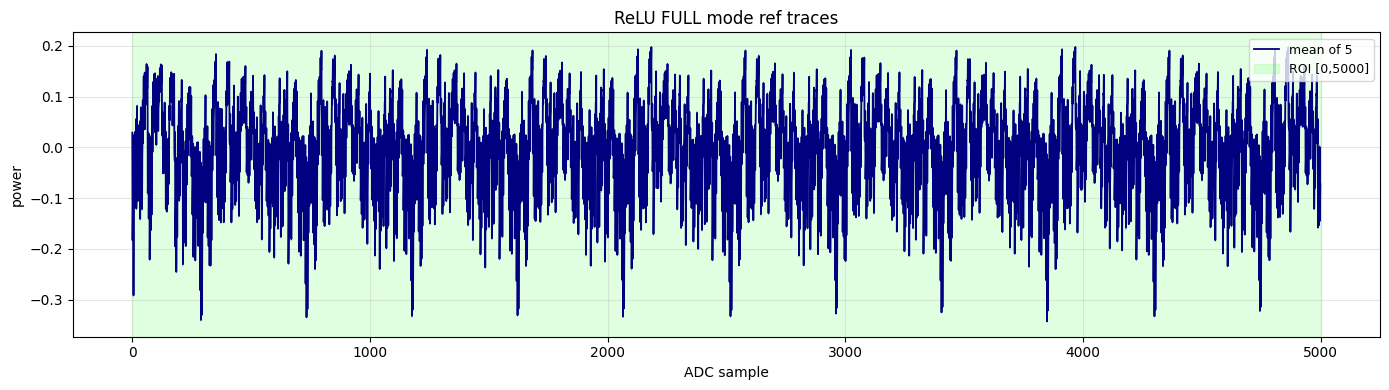

      ROI ADC=[0,5000]  ext=[0,3000]  n_ext=40
[2/3] coarse sweep: 5w * 3off * 40ext = 600 configs
  [1/600] w=1.0 off=10.0 ext=0  (consec_bad=0, total_bad=0/1805)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trig

  [20/600] w=1.0 off=10.0 ext=1425  (consec_bad=0, total_bad=6/1805)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trig

  [40/600] w=1.0 off=10.0 ext=2925  (consec_bad=0, total_bad=10/1805)


...

  [80/93] w=2.8 off=10.0 ext=1670  (consec_bad=0, total_bad=190/563)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARN

  [93/93] w=2.8 off=10.0 ext=1800  (consec_bad=0, total_bad=208/563)


,act_name,trigger_mode_name,trigger_start,trigger_stop,width,offset,ext_offset,n_runs,valid_runs,n_semantic_flip,...,semantic_flip_rate_over_valid_runs,finite_after_rate,pred_consistency_rate,bad_response_rate,capture_failure_rate,before_acc,after_acc,acc_drop,mean_margin_drop,mean_l1_diff
0,ReLU,FULL,0,64,2.2,10.0,1660,20,14,2,...,0.142857,0.70,0.70,0.3,0.00,1.0,0.857143,0.142857,-0.023175,5.310854
1,ReLU,FULL,0,64,2.5,10.0,1660,20,14,2,...,0.142857,0.70,0.70,0.3,0.00,1.0,0.857143,0.142857,-0.023175,5.310854
2,ReLU,FULL,0,64,2.8,10.0,1660,20,14,2,...,0.142857,0.70,0.70,0.3,0.00,1.0,0.857143,0.142857,-0.023175,5.310854
3,ReLU,FULL,0,64,2.5,10.0,1680,20,17,2,...,0.117647,0.85,0.85,0.1,0.05,1.0,0.882353,0.117647,-0.109866,4.063749
4,ReLU,FULL,0,64,2.2,10.0,1680,20,18,2,...,0.111111,0.90,0.90,0.1,0.00,1.0,0.888889,0.111111,-0.080365,4.994675


FULL-MODE EXPERIMENT — Sigmoid
[1/3] reference trace calibration (Sigmoid)
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] Sigmoid  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-sigmoid-CWLITEARM.hex


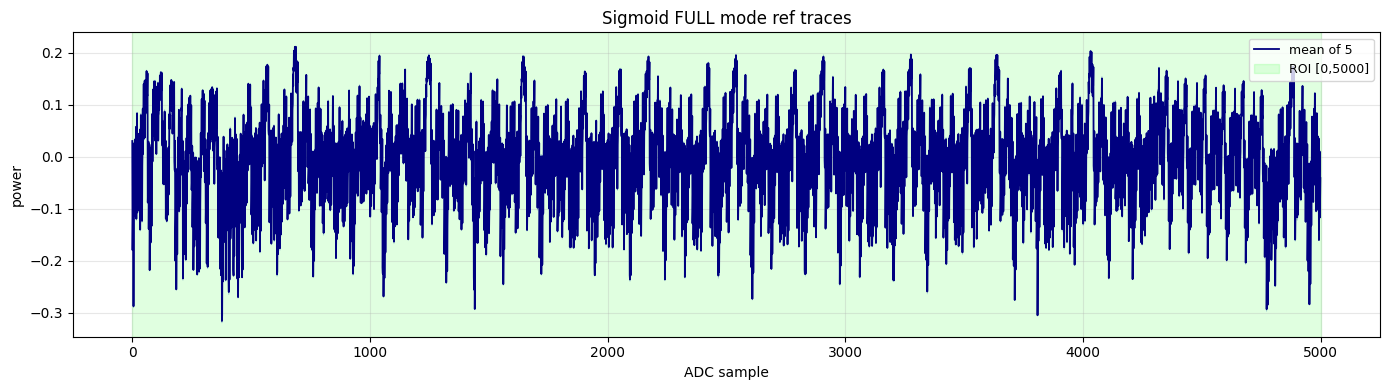

      ROI ADC=[0,5000]  ext=[0,3000]  n_ext=40
[2/3] coarse sweep: 5w * 3off * 40ext = 600 configs
  [1/600] w=1.0 off=10.0 ext=0  (consec_bad=0, total_bad=0/1805)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trig

  [20/600] w=1.0 off=10.0 ext=1425  (consec_bad=0, total_bad=4/1805)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  [40/600] w=1.0 off=10.0 ext=2925  (consec_bad=0, total_bad=6/1805)


...

(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  [93/93] w=1.8 off=10.0 ext=1725  (consec_bad=0, total_bad=229/563)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


,act_name,trigger_mode_name,trigger_start,trigger_stop,width,offset,ext_offset,n_runs,valid_runs,n_semantic_flip,...,semantic_flip_rate_over_valid_runs,finite_after_rate,pred_consistency_rate,bad_response_rate,capture_failure_rate,before_acc,after_acc,acc_drop,mean_margin_drop,mean_l1_diff
0,Sigmoid,FULL,0,64,1.5,10.0,1575,20,14,6,...,0.428571,0.7,0.7,0.3,0.0,1.0,0.571429,0.428571,-1.202111e+37,6.346349e+37
1,Sigmoid,FULL,0,64,1.5,10.0,1595,20,18,6,...,0.333333,0.9,0.9,0.1,0.0,1.0,0.666667,0.333333,-2.024994e+37,1.351838e+01
2,Sigmoid,FULL,0,64,1.8,10.0,1545,20,14,4,...,0.285714,0.7,0.7,0.3,0.0,1.0,0.714286,0.285714,-2.571750e+35,4.232918e+36
3,Sigmoid,FULL,0,64,1.8,10.0,1575,20,18,5,...,0.277778,0.9,0.9,0.1,0.0,1.0,0.722222,0.277778,-4.710909e+36,2.487048e+37
4,Sigmoid,FULL,0,64,1.8,10.0,1595,20,20,5,...,0.250000,1.0,1.0,0.0,0.0,1.0,0.750000,0.250000,-1.511422e+37,4.453494e-02


FULL-MODE EXPERIMENT — Tanh
[1/3] reference trace calibration (Tanh)
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] Tanh  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-tanh-CWLITEARM.hex


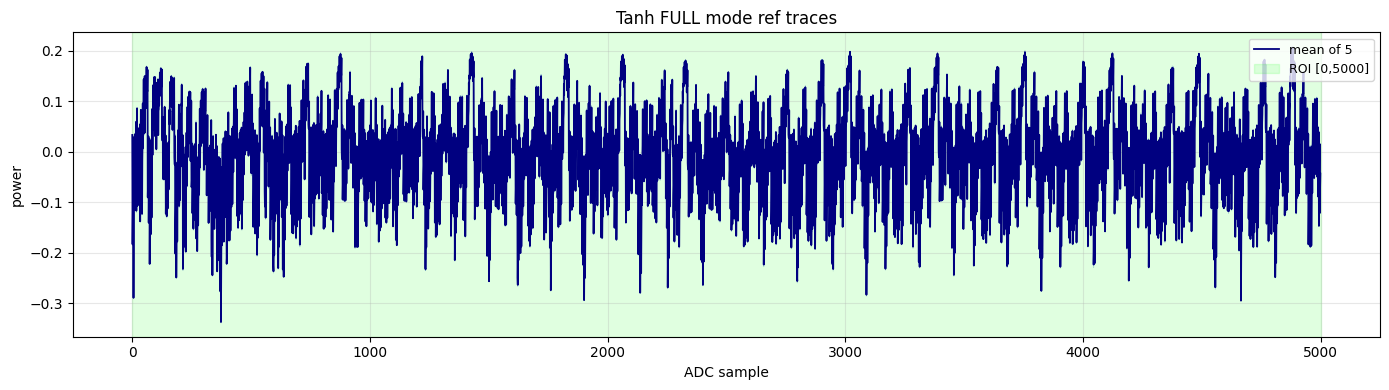

      ROI ADC=[0,5000]  ext=[0,3000]  n_ext=40
[2/3] coarse sweep: 5w * 3off * 40ext = 600 configs
  [1/600] w=1.0 off=10.0 ext=0  (consec_bad=0, total_bad=0/1805)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WA

  [20/600] w=1.0 off=10.0 ext=1425  (consec_bad=0, total_bad=7/1805)
  [40/600] w=1.0 off=10.0 ext=2925  (consec_bad=0, total_bad=7/1805)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trig

  [60/600] w=1.0 off=25.0 ext=1425  (consec_bad=0, total_bad=10/1805)


...

(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger se

  [93/93] w=3.3 off=10.0 ext=2325  (consec_bad=1, total_bad=178/563)


(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


,act_name,trigger_mode_name,trigger_start,trigger_stop,width,offset,ext_offset,n_runs,valid_runs,n_semantic_flip,...,semantic_flip_rate_over_valid_runs,finite_after_rate,pred_consistency_rate,bad_response_rate,capture_failure_rate,before_acc,after_acc,acc_drop,mean_margin_drop,mean_l1_diff
0,Tanh,FULL,0,64,3.0,10.0,2175,20,16,4,...,0.250000,0.80,0.80,0.20,0.00,1.0,0.750000,0.250000,-1.228262e+17,1.012904e+19
1,Tanh,FULL,0,64,3.0,10.0,2215,20,17,4,...,0.235294,0.85,0.85,0.15,0.00,1.0,0.764706,0.235294,-2.754563e+29,4.365016e+30
2,Tanh,FULL,0,64,2.7,10.0,2175,20,14,3,...,0.214286,0.70,0.70,0.25,0.05,1.0,0.785714,0.214286,-1.151619e+36,8.361083e+18
3,Tanh,FULL,0,64,3.3,10.0,2215,20,17,3,...,0.176471,0.85,0.85,0.15,0.00,1.0,0.823529,0.176471,-1.739440e+22,2.756403e+23
4,Tanh,FULL,0,64,3.3,10.0,2175,20,16,2,...,0.125000,0.80,0.80,0.20,0.00,1.0,0.875000,0.125000,-8.190523e+16,6.754421e+18


FULL-MODE EXPERIMENT — Extended_ReLU
[1/3] reference trace calibration (Extended_ReLU)
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 214411 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 214411 bytes
[flash] Extended_ReLU  <-  C:\Users\Admin\chipwhisperer\firmware\mcu\nn-all\nn-mnist-relu_ext-CWLITEARM.hex


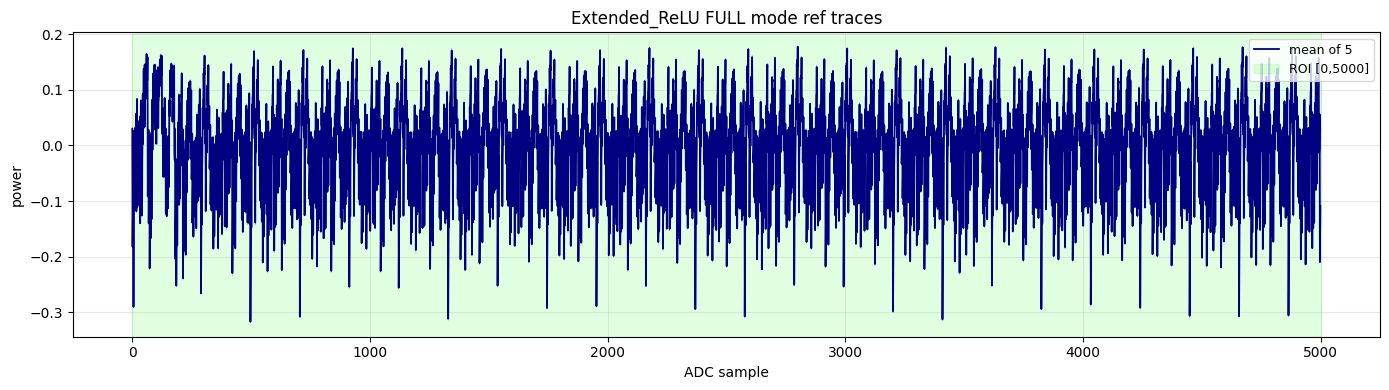

      ROI ADC=[0,5000]  ext=[0,3000]  n_ext=40
[2/3] coarse sweep: 5w * 3off * 40ext = 600 configs
  [1/600] w=1.0 off=10.0 ext=0  (consec_bad=0, total_bad=0/1805)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  [20/600] w=1.0 off=10.0 ext=1425  (consec_bad=0, total_bad=3/1805)


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:724) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


  [40/600] w=1.0 off=10.0 ext=2925  (consec_bad=0, total_bad=5/1805)
  [60/600] w=1.0 off=25.0 ext=1425  (consec_bad=0, total_bad=5/1805)


...

  [63/63] w=2.3 off=10.0 ext=2230  (consec_bad=0, total_bad=296/383)


(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 
(ChipWhisperer Target WARNING|File SimpleSerial2.py:533) Read timed out: 


,act_name,trigger_mode_name,trigger_start,trigger_stop,width,offset,ext_offset,n_runs,valid_runs,n_semantic_flip,...,semantic_flip_rate_over_valid_runs,finite_after_rate,pred_consistency_rate,bad_response_rate,capture_failure_rate,before_acc,after_acc,acc_drop,mean_margin_drop,mean_l1_diff
0,Extended_ReLU,WINDOW,40,48,1.7,10.0,2095,20,13,3,...,0.230769,0.65,0.65,0.35,0.00,1.0,0.769231,0.230769,-3.385238e+08,3.385238e+08
1,Extended_ReLU,WINDOW,40,48,2.3,10.0,2095,20,14,3,...,0.214286,0.70,0.70,0.30,0.00,1.0,0.785714,0.214286,-3.066848e+08,3.067053e+08
2,Extended_ReLU,WINDOW,40,48,1.7,10.0,2200,20,12,2,...,0.166667,0.60,0.60,0.40,0.00,1.0,0.833333,0.166667,-2.117697e+05,2.117754e+05
3,Extended_ReLU,WINDOW,40,48,2.0,10.0,2200,20,12,2,...,0.166667,0.60,0.60,0.40,0.00,1.0,0.833333,0.166667,-2.117697e+05,2.117754e+05
4,Extended_ReLU,WINDOW,40,48,1.7,10.0,2080,20,13,2,...,0.153846,0.65,0.65,0.30,0.05,1.0,0.846154,0.153846,-6.690098e+20,6.690098e+20



=== cross-activation comparison (FULL mode) ===


,activation,fair_model_mode,trigger_mode,best_width,best_offset,best_ext_offset,best_trig_start,best_trig_stop,n_runs,valid_runs,...,n_capture_no_trigger,n_crash_or_no_response,semantic_flip_rate,semantic_flip_rate_over_valid_runs,finite_after_rate,pred_consistency_rate,bad_response_rate,capture_failure_rate,clean_accuracy,clean_consistency
0,ReLU,True,FULL,2.2,10.0,1660,0,64,1860,1652,...,12,0,0.006989,0.007869,0.888172,0.888172,0.105376,0.006452,1.0,1.0
1,Sigmoid,True,FULL,1.5,10.0,1575,0,64,1860,1628,...,28,0,0.015591,0.017813,0.875269,0.875269,0.109677,0.015054,1.0,1.0
2,Tanh,True,FULL,3.0,10.0,2175,0,64,1860,1674,...,14,0,0.015591,0.017324,0.900000,0.900000,0.092473,0.007527,1.0,1.0
3,Extended_ReLU,True,FULL,2.0,10.0,1875,0,64,1860,1761,...,22,0,0.004301,0.004543,0.946774,0.946774,0.041398,0.011828,1.0,1.0


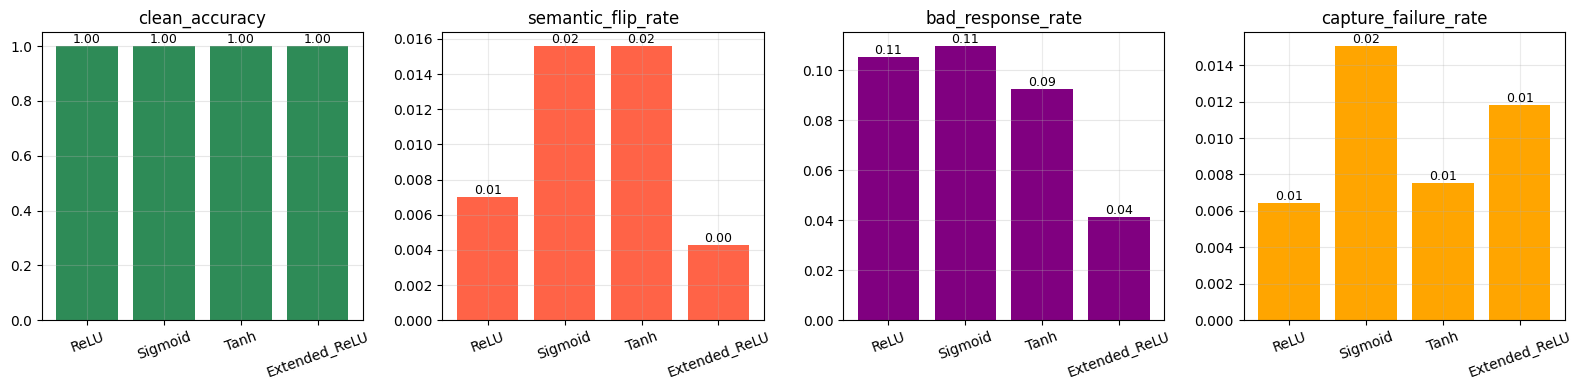


=== cross-activation comparison (WINDOW mode) ===


,activation,fair_model_mode,trigger_mode,best_width,best_offset,best_ext_offset,best_trig_start,best_trig_stop,n_runs,valid_runs,...,n_capture_no_trigger,n_crash_or_no_response,semantic_flip_rate,semantic_flip_rate_over_valid_runs,finite_after_rate,pred_consistency_rate,bad_response_rate,capture_failure_rate,clean_accuracy,clean_consistency
0,ReLU,True,WINDOW,1.7,10.0,266,56,64,1260,1044,...,18,0,0.000000,0.000000,0.828571,0.828571,0.157143,0.014286,1.0,1.0
1,Sigmoid,True,WINDOW,1.7,10.0,1589,0,8,1260,1100,...,18,0,0.025397,0.029091,0.873016,0.873016,0.112698,0.014286,1.0,1.0
2,Tanh,True,WINDOW,3.0,10.0,2020,16,24,1260,1165,...,14,0,0.007937,0.008584,0.924603,0.924603,0.064286,0.011111,1.0,1.0
3,Extended_ReLU,True,WINDOW,1.7,10.0,2095,40,48,1260,957,...,15,0,0.026190,0.034483,0.759524,0.759524,0.228571,0.011905,1.0,1.0


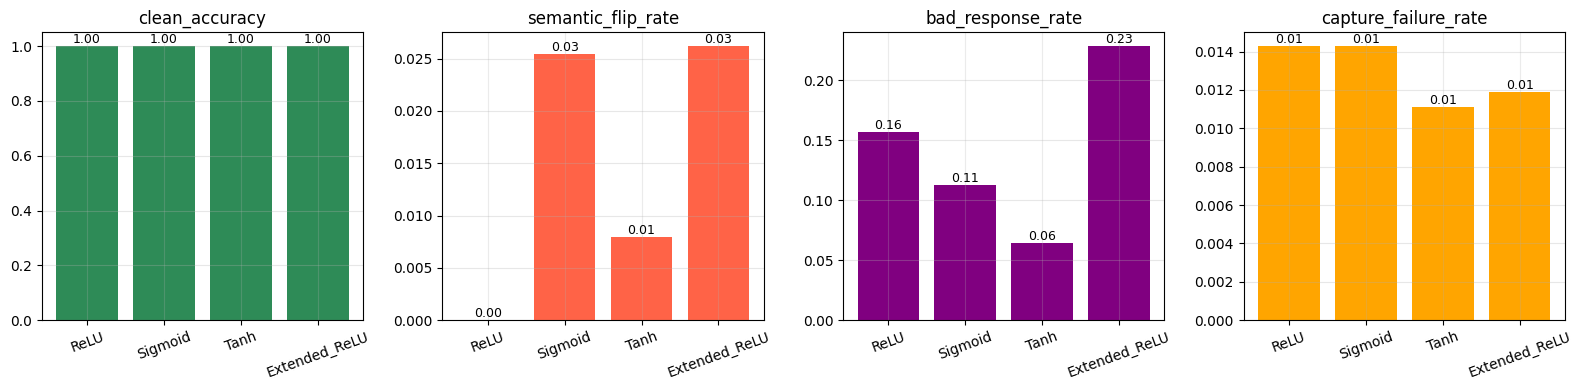


=== full vs window comparison ===


,activation,full_semantic_flip_rate,full_finite_after_rate,full_capture_failure_rate,full_bad_response_rate,window_semantic_flip_rate,window_finite_after_rate,window_capture_failure_rate,window_bad_response_rate,window_best
0,ReLU,0.006989,0.888172,0.006452,0.105376,0.000000,0.828571,0.014286,0.157143,"(56, 64)"
1,Sigmoid,0.015591,0.875269,0.015054,0.109677,0.025397,0.873016,0.014286,0.112698,"(0, 8)"
2,Tanh,0.015591,0.900000,0.007527,0.092473,0.007937,0.924603,0.011111,0.064286,"(16, 24)"
3,Extended_ReLU,0.004301,0.946774,0.011828,0.041398,0.026190,0.759524,0.011905,0.228571,"(40, 48)"


Main experiment function defined. Uncomment the call above to run it.


In [30]:
def run_all_activations_main():
    full_experiments   = {}
    window_experiments = {}

    # Measure clean baseline accuracy first (quick confidence check)
    print('\n=== clean baseline accuracy ===')
    # baseline_df = measure_baseline_accuracy(
    #     test_imgs, test_lbls, test_names,
    #     activations=list(ALL_ACTIVATIONS.keys()),
    #     n_images=min(len(test_imgs), 10),
    # )
    baseline_df = run_clean_accuracy_check(
        n_images=50,
        activations=list(ALL_ACTIVATIONS.keys()),
        save=True,
    )
    full_experiments = {}
    window_experiments = {}

    print('\n=== FULL-mode experiments ===')
    for act_name in ALL_ACTIVATIONS:
        full_experiments[act_name] = run_full_mode_experiment(act_name, quick=False)

    print('\n=== WINDOW-mode experiments ===')
    for act_name in ALL_ACTIVATIONS:
        window_experiments[act_name] = run_window_mode_experiment(act_name, quick=False)

    print('\n=== cross-activation comparison (FULL mode) ===')
    full_summary = build_cross_activation_summary(full_experiments, baseline_df=baseline_df)
    display(full_summary)
    full_summary.to_csv(RESULTS_ROOT / 'cross_activation_full_mode.csv', index=False)
    plot_cross_activation_summary(full_summary,
                                    save_path=RESULTS_ROOT / 'cross_activation_full_mode.png')
    
    print('\n=== cross-activation comparison (WINDOW mode) ===')
    window_summary = build_cross_activation_summary(window_experiments, baseline_df=baseline_df)
    display(window_summary)
    window_summary.to_csv(RESULTS_ROOT / 'cross_activation_window_mode.csv', index=False)
    plot_cross_activation_summary(window_summary,
                                    save_path=RESULTS_ROOT / 'cross_activation_window_mode.png')

    print('\n=== full vs window comparison ===')
    fvw = full_vs_window_summary(full_experiments, window_experiments)
    display(fvw)
    fvw.to_csv(RESULTS_ROOT / 'full_vs_window.csv', index=False)

    return {
        'baseline_df': baseline_df,
        'full_experiments': full_experiments,
        'window_experiments': window_experiments,
        'full_summary': full_summary,
        'window_summary': window_summary,
        'full_vs_window': fvw,
    }

MAIN_RESULTS = run_all_activations_main()
print('Main experiment function defined. Uncomment the call above to run it.')


In [ ]:
scope.io.hs2 = 'clkgen'
try: target.dis()
except Exception: pass
try: scope.dis()
except Exception: pass
print('hardware disconnected')

In [2]:
jupyter nbconvert --to html file.ipynb

SyntaxError: invalid syntax (908579880.py, line 1)